In [1]:
# Import von Bibliotheken
from datasets import load_dataset
import urllib.request
import io,re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
# Einlesen weiterer Bibliotheken
import os
# Deutsche Stopwörter laden
!pip install nltk
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords = stopwords.words('german')

from sklearn.feature_extraction.text import CountVectorizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
!pip install sentence-transformers

[nltk_data] Downloading package punkt to /home/haloh001/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/haloh001/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
!pip install "transformers==4.47.1" "sentence-transformers"
from sentence_transformers import SentenceTransformer

In [3]:
!pip install bertopic
!pip uninstall -y umap umap-learn
!pip install umap-learn
from umap import UMAP
import hdbscan
import umap
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

Found existing installation: umap-learn 0.5.12
Uninstalling umap-learn-0.5.12:
  Successfully uninstalled umap-learn-0.5.12
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
Using cached umap_learn-0.5.12-py3-none-any.whl (91 kB)


In [4]:
# Einlesen der Langwahlprogramme (aus JSON-Format in ein Wörterbuch)

# für CDU/CSU
with open("cdu-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    CDU_text_json = json.load(datei)

# für SPD
with open("spd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    SPD_text_json = json.load(datei)

# für Die Linke
with open("linke-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Linke_text_json = json.load(datei)

# für die AfD
with open("afd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    AfD_text_json = json.load(datei)

# für Bündnis 90/Grüne
with open("gruene-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Grüne_text_json = json.load(datei)

# für FDP
with open("fdp-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    FDP_text_json = json.load(datei)

In [5]:
# Überführen aller 'eigentlichen' Texte in eine Liste pro Partei, d.h. ohne Kapitelüberschriften

# Suchfunktion in den "Partei-Wörterbüchern"

def finde_gefilterte_texte(struktur):
    ergebnisse = []
    
    # Fall A: Wenn das aktuelle Element ein Dictionary ist
    if isinstance(struktur, dict):
        # Typ/Art auslesen (liefert None, wenn der Schlüssel fehlt)
        aktueller_typ = struktur.get('type') or struktur.get('art')            # nur Suchen in diesen Elementen
        
        # Prüfen, ob 'text' existiert und der gefundene Typ gültig ist
        if 'text' in struktur and aktueller_typ in ['paragraph', 'bullet', 'absatz']:   # nur Texte überführen mit diesem Typ
            ergebnisse.append(struktur['text'])
        
        # Tiefer in alle Werte schauen für eventuelle Verschachtelungen
        for wert in struktur.values():
            ergebnisse.extend(finde_gefilterte_texte(wert))
                
    # Fall B: Wenn das aktuelle Element eine Liste ist
    elif isinstance(struktur, list):
        for element in struktur:
            ergebnisse.extend(finde_gefilterte_texte(element))
            
    return ergebnisse

CDU_text = finde_gefilterte_texte(CDU_text_json)
CDU_text = CDU_text[135:]   # da vor der eigentlichen Langfassung im CDU/CSU-Programm noch eine Kurzfassung vorangeht, wird diese ausgeblendet
SPD_text = finde_gefilterte_texte(SPD_text_json)
Linke_text = finde_gefilterte_texte(Linke_text_json)
Grüne_text = finde_gefilterte_texte(Grüne_text_json)
AfD_text = finde_gefilterte_texte(AfD_text_json)
FDP_text = finde_gefilterte_texte(FDP_text_json)

In [6]:
# durchschnittliche Anzahl der Länge jedes einzelnen Dokuments pro Partei VOR BEREINIGUNG
# zur Orientierung die Anzahl der Absätze mit einer Länge von max. 100 Zeichen
durchschnitt_CDU = round(sum(len(s) for s in CDU_text) / len(CDU_text),1)
anzahl_CDU = len([i for i in CDU_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im CDU-Programm: ",durchschnitt_CDU)
print("Anzahl aller Absätze: ",len(CDU_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU)
print("-----")
durchschnitt_SPD = round(sum(len(s) for s in SPD_text) / len(SPD_text),1)
anzahl_SPD = len([i for i in SPD_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im SPD-Programm: ",durchschnitt_SPD)
print("Anzahl aller Absätze: ",len(SPD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD)
print("-----")
durchschnitt_Linke = round(sum(len(s) for s in Linke_text) / len(Linke_text),1)
anzahl_Linke = len([i for i in Linke_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im Linke-Programm: ",durchschnitt_Linke)
print("Anzahl aller Absätze: ",len(Linke_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke)
print("-----")
durchschnitt_AfD = round(sum(len(s) for s in AfD_text) / len(AfD_text),1)
anzahl_AfD = len([i for i in AfD_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im AfD-Programm: ",durchschnitt_AfD)
print("Anzahl aller Absätze: ",len(AfD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD)
print("-----")
durchschnitt_Grüne = round(sum(len(s) for s in Grüne_text) / len(Grüne_text),1)
anzahl_Grüne = len([i for i in Grüne_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne)
print("Anzahl aller Absätze: ",len(Grüne_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne)
print("-----")
durchschnitt_FDP = round(sum(len(s) for s in FDP_text) / len(FDP_text),1)
anzahl_FDP = len([i for i in FDP_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im FDP-Programm: ",durchschnitt_FDP)
print("Anzahl aller Absätze: ",len(FDP_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP)
print("-----")

Durchschnittliche Zeichenlänge eines Absatzes im CDU-Programm:  280.7
Anzahl aller Absätze:  660
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  123
-----
Durchschnittliche Zeichenlänge eines Absatzes im SPD-Programm:  465.3
Anzahl aller Absätze:  444
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  15
-----
Durchschnittliche Zeichenlänge eines Absatzes im Linke-Programm:  380.0
Anzahl aller Absätze:  665
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  30
-----
Durchschnittliche Zeichenlänge eines Absatzes im AfD-Programm:  299.6
Anzahl aller Absätze:  717
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108
-----
Durchschnittliche Zeichenlänge eines Absatzes im Grüne-Programm:  649.5
Anzahl aller Absätze:  583
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  7
-----
Durchschnittliche Zeichenlänge eines Absatzes im FDP-Programm:  751.7
Anzahl aller Absätze:  200
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  1
-----


In [7]:
# Ziele:
# 1.) bestimmte String-Elemente / Absätze löschen, da diese für BERTopic u. U. sehr kurz sind, wie z.B. kurze Überschriften usw.
#     die Absätze der CDU/CSU- und AfD-Wahlprogramme sind im Vergleich im Schnitt viel kürzer als die der anderen Parteien
#
# 2.) nacheinander folgende bullet points zusammenfügen, da diese höchstwahrscheinlich zum selben Thema gehören;
#     auch zwecks Vermeidung einer möglichen Ungleichgewichtung, da jeder Absatz unabhängig seiner Länge als einzelnes Dokument gezählt wird.
#     Somit fallen einzelne kurze bullet points ungleich höher ins Gewicht als z.B. ein längerer ausformulierter Satz
#     Beispiel:
#     Textkorpus über 2 Themencluster 'Gesundheit' und 'Bildung'
#     9 einzelne Sätze in bullet-points-Form zur Gesundheit sowie 9 lange Sätze als 1 zusammenhängender Absatz zum Thema Bildung
#     würden ohne diesen Ansatz annahmegemäß zwar korrekt geclustert, aber im 'falschen' Verhältnis:
#     Statt 1:1 (9 x 1 kurze Sätze vs. 1 x 9 lange Sätze als ganzer Absatz) würden die einzelnen Dokumente mit 9:1 gewertet
#     und so getan, also ob der Text 9 mal mehr über Gesundheit statt über Bildung 'spricht', obwohl die Zeichenlänge identisch ist

# SCHRITT 1: LÖSCHEN VON ABSÄTZEN (für Ziel 1)
# sich pro Partei einzelne Absätze anzeigen lassen mit jeweils einer maximalen Länge von x Zeichen
# um fallbezogen zu entscheiden, bis zu welcher Länge bzw. welche Absätze ggf. manuell gelöscht werden müssen

In [8]:
# für das Wahlprogramm der FDP

for index, i in enumerate(FDP_text):
  if len(i) < 150:
    print(index, i)

1 Denn: Alles lässt sich ändern.


In [9]:
FDP_text = [text for text in FDP_text if len(text) >= 60]
durchschnitt_FDP_neu = round(sum(len(s) for s in FDP_text) / len(FDP_text),1)
anzahl_FDP_neu = len([i for i in FDP_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im FDP-Programm: ",durchschnitt_FDP_neu, "(alt: ",durchschnitt_FDP, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP_neu, "(alt: ",anzahl_FDP, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im FDP-Programm:  755.3 (alt:  751.7 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  0 (alt:  1 )


In [10]:
# für das Wahlprogramm der SPD

for index, i in enumerate(SPD_text):
  if len(i) < 125:
    print(index, i)

1 Deutschland steht vor bedeutenden Entscheidungen:
2 • Investieren wir jetzt weiter kraftvoll in unser Land? Oder lassen wir unsere Bahn, unsere Straßen und Brücken verkommen?
8 Selten in den vergangenen Jahrzehnten waren klare Haltung, Charakter und Erfahrung so entscheidend.
11 Dafür stehen wir.
13 Wir sagen: Das alles schadet Deutschland. Das ist nicht unser Weg.
22 Genau deshalb braucht Deutschland in dieser schwierigen Zeit eine starke SPD:
24 • Wir investieren weiter in Schienen, Brücken und digitale Netze.
28 • Wir kämpfen für innere und äußere Sicherheit und stellen uns den Feinden der offenen Gesellschaft konsequent entgegen.
29 • Wir sorgen dafür, dass Kitas und Schulen zuverlässig an der Seite der Familien stehen.
33 Politik mit Maß und Mitte, die verbindet und nicht spaltet.
34 Darauf kommt es jetzt an.
35 Darüber entscheiden die Wählerinnen und Wähler bei der Bundestagswahl am 23. Februar 2025.
49 Wir werden außerdem den Kauf von E-Autos stärker ankurbeln.
52 Wir können e

In [11]:
# Herauslöschen der unerwünschten Texte
# wir gehen nicht nach Länge, da teils längere Text inhaltslos sind und kürzere nicht
# manuelles Löschen bevorzugt statt pauschales Löschen z.B. "alles < 60 Zeichen"

# einzelne Löschen von Indizes verschiebt diese, daher der Weg über eine Liste
loesch_indizes = {1, 8, 11, 13, 22, 33, 34, 35, 52}

# Neue Liste erstellen ohne die unerwünschten Indizes
SPD_text = [element for index, element in enumerate(SPD_text) if index not in loesch_indizes]

durchschnitt_SPD_neu = round(sum(len(s) for s in SPD_text) / len(SPD_text),1)
anzahl_SPD_neu = len([i for i in SPD_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im SPD-Programm: ",durchschnitt_SPD_neu, "(alt: ",durchschnitt_SPD, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD_neu, "(alt: ",anzahl_SPD, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im SPD-Programm:  473.6 (alt:  465.3 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  6 (alt:  15 )


In [12]:
# für das Wahlprogramm der Linke

for index, i in enumerate(Linke_text):
  if len(i) < 110:
    print(index, i)

13 Unsere Leitlinie heißt: Wir gemeinsam gegen die da oben.
46 ▪ Die Grundsteuer darf nicht mehr als Teil der Betriebskosten auf die Mieter*innen umgelegt werden.
55 ▪ Investitionen in den sozialen Wohnungsbau müssen von der Schuldenbremse ausgenommen werden.
75 Geschätzte jährliche Mehreinnahmen: 108 Milliarden Euro
93 Geschätzte jährliche Mehreinnahmen: 17 Milliarden Euro
101 Geschätzte jährliche Mehreinnahmen: 42 Milliarden Euro
104 Geschätzte jährliche Mehreinnahmen: 18 Milliarden Euro
106 Geschätzte jährliche Mehreinnahmen: 36 Milliarden Euro
115 Geschätzte jährliche Mehreinnahmen: 18 Milliarden Euro
159 ▪ Wir setzen uns zudem für eine Stärkung der Kinder- und Jugendhilfe ein.
161 Senior*innen müssen in allen gesellschaftlichen Bereichen gleichberechtigt teilhaben können.
205 ▪ Wir stärken Präventions-, Beratungs- und Hilfsangebote.
287 ▪ für eine Anschubfinanzierung für neue Batterietechnologien und Energiespeicher;
305 ▪ Wir wollen die KfZ-Steuer neugestalten und große und schwe

In [13]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {13, 75, 93, 101, 104, 106, 115}
Linke_text = [element for index, element in enumerate(Linke_text) if index not in loesch_indizes]

durchschnitt_Linke_neu = round(sum(len(s) for s in Linke_text) / len(Linke_text),1)
anzahl_Linke_neu = len([i for i in Linke_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im Linke-Programm: ",durchschnitt_Linke_neu, "(alt: ",durchschnitt_Linke, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke_neu, "(alt: ",anzahl_Linke, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im Linke-Programm:  383.5 (alt:  380.0 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  23 (alt:  30 )


In [14]:
# für das Wahlprogramm der Grüne

for index, i in enumerate(Grüne_text):
  if len(i) < 170:
    print(index, i)

8 Nehmen wir unsere ökologische und ökonomische Zukunft in die Hand! Wachsen wir in die Zukunft!
10 Das verlangt von der Politik: Kurs halten. Verlässlichkeit herstellen. Regeln und Normen vereinfachen. Kurz: mehr ermöglichen.
13 Nehmen wir unsere soziale Zukunft in die Hand! Sorgen wir dafür, dass alle Menschen fair dabei sind und die Dinge des alltäglichen Lebens bezahlbar sind!
16 Nehmen wir unsere gesellschaftliche und demokratische Zukunft in die Hand! Sichern wir unseren Frieden in Freiheit!
23 Dafür bitten wir bei der kommenden Bundestagswahl um Ihr Vertrauen und Ihre Stimme!
24 Nehmen wir unsere Zukunft zusammen in die Hand! Wachsen wir zusammen!
92 Wir werden unsere öffentliche Verwaltung konsequent modernisieren, digitalisieren und an den Bedürfnissen der Menschen ausrichten.
164 Unsere Kulturlandschaft ist Lebensraum vieler gefährdeter Arten – wir wollen Landnutzung und Naturschutz in Einklang bringen.
186 Die Meeres- und Polarforschung liefert dafür wichtige Beiträge. Wir s

In [15]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {8, 10, 13, 16, 23, 24}
Grüne_text = [element for index, element in enumerate(Grüne_text) if index not in loesch_indizes]

durchschnitt_Grüne_neu = round(sum(len(s) for s in Grüne_text) / len(Grüne_text),1)
anzahl_Grüne_neu = len([i for i in Grüne_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne_neu, "(alt: ",durchschnitt_Grüne, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne_neu, "(alt: ",anzahl_Grüne, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im Grüne-Programm:  655.2 (alt:  649.5 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  4 (alt:  7 )


In [16]:
# für das Wahlprogramm der AfD

for index, i in enumerate(AfD_text):
  if len(i) < 200:
    print(index, i)

0 Wir stehen fest zu den Prinzipien der Sozialen Marktwirtschaft, die seit Jahrzehnten Wohlstand und sozialen Frieden in unserem Land sichern.
3 Wir treten dafür ein, dass Arbeitnehmer immer deutlich bessergestellt sind als Empfänger von Sozialleistungen. Ihre Arbeit soll eine auskömmliche und sichere Rente gewährleisten.
12 Vor allem für Mittelstand und Landwirtschaft sind die strangulierenden Vorgaben der Politik nicht mehr zu bewältigen. Viele Betriebe geben auf oder suchen neue Chancen im Ausland.
15 Damit Unternehmer an die Zukunft des Standorts Deutschland glauben können, werden wir den Zugang zu sicherer und bezahlbarer Energie wiederherstellen durch:
16 • Verlängerung der Laufzeiten der Kohlekraftwerke
17 • Wiedereinstieg in die Nutzung der Kernenergie
18 • Reparatur und Wiederinbetriebnahme der Nord-Stream-Pipelines
19 • Aufhebung des Verbots von Gas- und Ölheizungen
20 • Abschaffung der CO₂-Abgabe
21 • Reduzierung der Energiesteuer und Senkung der Stromsteuer auf das Minimum


In [17]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {0,}
AfD_text = [element for index, element in enumerate(AfD_text) if index not in loesch_indizes]

durchschnitt_AfD_neu = round(sum(len(s) for s in AfD_text) / len(AfD_text),1)
anzahl_AfD_neu = len([i for i in AfD_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im AfD-Programm: ",durchschnitt_AfD_neu, "(alt: ",durchschnitt_AfD, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD_neu, "(alt: ",anzahl_AfD, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im AfD-Programm:  299.8 (alt:  299.6 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108 (alt:  108 )


In [18]:
# für das Wahlprogramm der CDU

for index, i in enumerate(CDU_text):
  if len(i) < 90:
    print(index, i)

6 Wir wollen ein Land, das wieder Wohlstand für alle schafft.
7 Wir wollen ein Land, das frei und wieder sicher ist.
8 Wir wollen ein Land, das wieder zusammenhält.
9 Wir wollen Deutschland wieder nach vorne bringen.
10 Ein Deutschland, auf das wir wieder stolz sein können.
13 Wir wollen ein Land, das wieder Wohlstand für alle schafft.
14 Wir wollen Deutschland wieder nach vorne bringen.
15 Ein Deutschland, auf das wir wieder stolz sein können.
16 Unser Plan:
17 Leistung muss sich wieder lohnen.
18 Arbeitsrecht modernisieren.
19 Arbeits- und Fachkräfte gewinnen.
20 Wir handeln.
41 Unser Plan:
42 Steuerlast verringern.
43 Bürokratie spürbar abbauen.
44 Steuern vereinfachen.
45 Resilienz der Wirtschaft stärken.
46 Freien Handel und Exporte unterstützen.
47 Wir handeln.
96 Unser Plan:
97 Für bezahlbare Energie sorgen.
98 Bei Energieinnovationen Spitze sein.
99 Wir handeln.
118 Unser Plan:
119 Klimaziele einhalten.
120 Emissionshandel richtig umsetzen.
121 Ressourcen nachhaltig nutzen.
122

In [19]:
# Anderer Ansatz: Herauslöschen der Strings unter 90 Zeichen
# diese fassen im Vorfeld die Punkte zusammen, die anschließend ausführlich in längeren Fließtexten samt bullet points folgen

CDU_text = [text for text in CDU_text if len(text) >= 89]

durchschnitt_CDU_neu = round(sum(len(s) for s in CDU_text) / len(CDU_text),1)
anzahl_CDU_neu = len([i for i in CDU_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im CDU-Programm: ",durchschnitt_CDU_neu, "(alt: ",durchschnitt_CDU, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU_neu, "(alt: ",anzahl_CDU, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im CDU-Programm:  336.5 (alt:  280.7 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  2 (alt:  123 )


In [20]:
# aktualisierte durchschnittliche Länge jedes einzelnen Dokuments pro Partei NACH BEREINIGUNG
print("Durchschnittliche Länge eines Absatzes im CDU-Programm: ",durchschnitt_CDU_neu)
print("Anzahl der Gesamtabsätze: ",len(CDU_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_CDU_neu/len(CDU_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im SPD-Programm: ",durchschnitt_SPD_neu)
print("Anzahl der Gesamtabsätze: ",len(SPD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_SPD_neu/len(SPD_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im Linke-Programm: ",durchschnitt_Linke_neu)
print("Anzahl der Gesamtabsätze: ",len(Linke_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_Linke_neu/len(Linke_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im AfD-Programm: ",durchschnitt_AfD_neu)
print("Anzahl der Gesamtabsätze: ",len(AfD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_AfD_neu/len(AfD_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne_neu)
print("Anzahl der Gesamtabsätze: ",len(Grüne_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_Grüne_neu/len(Grüne_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im FDP-Programm: ",durchschnitt_FDP_neu)
print("Anzahl der Gesamtabsätze: ",len(FDP_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_FDP_neu/len(FDP_text)*100,2))
print("-----")

Durchschnittliche Länge eines Absatzes im CDU-Programm:  336.5
Anzahl der Gesamtabsätze:  539
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  2
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  0.37
-----
Durchschnittliche Länge eines Absatzes im SPD-Programm:  473.6
Anzahl der Gesamtabsätze:  435
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  6
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  1.38
-----
Durchschnittliche Länge eines Absatzes im Linke-Programm:  383.5
Anzahl der Gesamtabsätze:  658
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  23
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  3.5
-----
Durchschnittliche Länge eines Absatzes im AfD-Programm:  299.8
Anzahl der Gesamtabsätze:  716
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  15.08
-----
Durchschnittliche Länge eines Absatzes im Grüne-Programm:  655.2
Anzahl der Gesamtabsätze:  577
Anzahl 

In [21]:
# SCHRITT 2: ZUSAMMENFASSEN DER BULLET POINTS UND ANHÄNGEN DIESER 'GESAMMELTEN BULLET POINTS'
#            an an den vorherigen (normalen Fließtext-)Absatz (für Ziel 2)

# zunächst die Ermittlung wie viele Absätze 'bullet points' sind, d.h. mit Sonderzeichen wie Bindestrich oder '•' beginnen

print(f"Gefundene Strings im CDU/CSU-Wahlprogramm: {len(s := [t for t in CDU_text if t and not t[0].isalpha()])} von {len(CDU_text)} ({(len(s)/len(CDU_text)*100 if CDU_text else 0):.2f}%)")
print(f"Gefundene Strings im SPD-Wahlprogramm: {len(s := [t for t in SPD_text if t and not t[0].isalpha()])} von {len(SPD_text)} ({(len(s)/len(SPD_text)*100 if SPD_text else 0):.2f}%)")
print(f"Gefundene Strings im Linke-Wahlprogramm: {len(s := [t for t in Linke_text if t and not t[0].isalpha()])} von {len(Linke_text)} ({(len(s)/len(Linke_text)*100 if Linke_text else 0):.2f}%)")
print(f"Gefundene Strings im Grüne-Wahlprogramm: {len(s := [t for t in Grüne_text if t and not t[0].isalpha()])} von {len(Grüne_text)} ({(len(s)/len(Grüne_text)*100 if Grüne_text else 0):.2f}%)")
print(f"Gefundene Strings im AfD-Wahlprogramm: {len(s := [t for t in AfD_text if t and not t[0].isalpha()])} von {len(AfD_text)} ({(len(s)/len(AfD_text)*100 if AfD_text else 0):.2f}%)")
print(f"Gefundene Strings im FDP-Wahlprogramm: {len(s := [t for t in FDP_text if t and not t[0].isalpha()])} von {len(FDP_text)} ({(len(s)/len(FDP_text)*100 if FDP_text else 0):.2f}%)")


Gefundene Strings im CDU/CSU-Wahlprogramm: 459 von 539 (85.16%)
Gefundene Strings im SPD-Wahlprogramm: 16 von 435 (3.68%)
Gefundene Strings im Linke-Wahlprogramm: 481 von 658 (73.10%)
Gefundene Strings im Grüne-Wahlprogramm: 0 von 577 (0.00%)
Gefundene Strings im AfD-Wahlprogramm: 216 von 716 (30.17%)
Gefundene Strings im FDP-Wahlprogramm: 0 von 199 (0.00%)


In [22]:
# Für das AfD-Wahlprogramm wird daher dieser Schritt vorgenommen.
#
# Trotz der hohen Anzahl im CDU/CSU- sowie Linken-Wahlprogramm wird für diese Parteien davon abgesehen
# da die einzelnen Absätze an sich nicht sehr kurz sind, und somit auch das Verhältnis dieser Absätze
# an der Gesamtanzahl verhältnismäßig zur AfD sehr gering ist

In [23]:
# Formel 
def merge_non_alpha_with_previous(input_list):
    result = []
    current_group = []

    for item in input_list:
        # Entfernt führende Leerzeichen für die Prüfung
        stripped_item = item.strip()

        if not stripped_item:
            continue  # Leere Strings überspringen

        # Prüfen, ob der String NICHT mit einem Buchstaben (A-Z, a-z, Umlaute) beginnt
        # ^[^a-zA-ZäöüÄÖÜß] bedeutet: Beginnt mit einem Zeichen, das kein Buchstabe ist
        if re.match(r"^[^a-zA-ZäöüÄÖÜß]", stripped_item):
            # Bereinigung: Alle führenden Nicht-Buchstaben/Nicht-Zahlen entfernen
            # ^[^a-zA-Z0-9äöüÄÖÜß]+ entfernt z.B. "🔘 ", "- ", "* " am Anfang
            cleaned_item = re.sub(r"^[^a-zA-Z0-9äöüÄÖÜß]+", "", stripped_item)
            current_group.append(cleaned_item)
        else:
            # Wenn ein normaler Text kommt, verarbeiten wir die vorherige Gruppe
            if current_group:
                combined_buttons = ", ".join(current_group)
                if result:
                    result[-1] = f"{result[-1]} {combined_buttons}"
                else:
                    result.append(combined_buttons)
                current_group = []

            result.append(item)

    # Letzte Gruppe am Ende der Liste verarbeiten
    if current_group:
        combined_buttons = ". ".join(current_group)
        if result:
            result[-1] = f"{result[-1]} {combined_buttons}"
        else:
            result.append(combined_buttons)

    return result

In [24]:
# Anwendung der Formel
AfD_text = merge_non_alpha_with_previous(AfD_text)

# Neuberechnung
durchschnitt_AfD_neu = round(sum(len(s) for s in AfD_text) / len(AfD_text),1)
anzahl_AfD_neu = len([i for i in AfD_text if len(i) < 100])

print("Durchschnittliche Länge eines Absatzes im AfD-Programm: ",durchschnitt_AfD_neu)
print("Anzahl der Gesamtabsätze: ",len(AfD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_AfD_neu/len(AfD_text)*100,2))

Durchschnittliche Länge eines Absatzes im AfD-Programm:  429.2
Anzahl der Gesamtabsätze:  500
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  13
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  2.6


In [25]:
cdu_avg_length = 281
spd_avg_length = 465
linke_avg_length = 380
grüne_avg_length = 650
afd_avg_length = 300
fdp_avg_length = 752

In [26]:
# für 'CDU_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in CDU_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(cdu_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_cdu = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_cdu.append(x)

In [27]:
# für 'SPD_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in SPD_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(spd_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_spd = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_spd.append(x)

In [28]:
# für 'Linke_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in Linke_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(linke_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_linke = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_linke.append(x)

In [29]:
# für 'Grüne_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in Grüne_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(grüne_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_grüne = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_grüne.append(x)

In [30]:
# für 'AfD_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in AfD_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(afd_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_afd = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_afd.append(x)

In [31]:
# für 'FDP_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in FDP_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(fdp_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_fdp = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_fdp.append(x)

In [32]:
import urllib.request, urllib.parse, urllib.error
stammdaten = ("MDB_STAMMDATEN.XML")  # mit den Parteizugehörigkeiten
from bs4 import BeautifulSoup
with open(stammdaten, "r", encoding="utf-8") as f:
  	soup2 = BeautifulSoup(f, "xml")

redner_id_mdb = dict()
for mdb in soup2.find_all("MDB"):
	id_tag = mdb.find("ID")
	party_tag = mdb.find("PARTEI_KURZ")
	mdb_id = id_tag.text if id_tag else None
	party = party_tag.text if party_tag else None
	redner_id_mdb[mdb_id] = party

# da wo keine Parteizugehörigkeit aus den Stammdaten ersichtlich, manuelles Hinzufügen diverser Nummern
redner_id_mdb["11002735"]  # MERZ
redner_id_mdb["999990151"] = "SPD"
redner_id_mdb["999990133"] = "SPD"
redner_id_mdb["999990074"] = "SPD"
redner_id_mdb["11005217 999990074"] = "SPD"
redner_id_mdb["999990119"] = "SPD"
redner_id_mdb["999990149"] = "SPD"
redner_id_mdb["999990080"] = "parteilos"
redner_id_mdb["999990142"] = "parteilos"
redner_id_mdb["999990154"] = "parteilos"
redner_id_mdb["999990152"] = "CDU"
redner_id_mdb["999990153"] = "CDU"
redner_id_mdb["999990150"] = "CDU"
redner_id_mdb["999990141"] = "CSU"
redner_id_mdb["999990193"] = "SPD"
redner_id_mdb["999990093"] = "SPD"
redner_id_mdb["999990120"] = "SPD"
redner_id_mdb["999990129"] = "SPD"
redner_id_mdb["999990145"] = "SPD"
redner_id_mdb["999990144"] = "CDU"
redner_id_mdb["999990125"] = "CDU"
redner_id_mdb["999990147"] = "CSU"
redner_id_mdb["999990146"] = "SPD"
redner_id_mdb["999990121"] = "SPD"
redner_id_mdb["999990148"] = "SPD"
redner_id_mdb["999990122"] = "BÜNDNIS 90/DIE GRÜNEN"
redner_id_mdb["999990123"] = "DIE LINKE"
redner_id_mdb["999990148"] = "SPD"
redner_id_mdb["999990122"] = "BÜNDNIS 90/DIE GRÜNEN"
redner_id_mdb["999990123"] = "DIE LINKE"
redner_id_mdb["999990124"] = "SPD"
redner_id_mdb["999990078"] = "FDP"
redner_id_mdb["999990082"] = "SPD"

In [33]:
# Import der Bundestagsreden via gültigem API-Key für die 5 Betrachtungszeiträume
# API-Key gültig bis zunächst Ende Mai 2027
api = "R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ"

# Eingrenzung Zeitraum Nr. 1, Umwandlung in json-Format & Extraktion der XML-URLs (=Protokolle) aus dem Dictionary
html_zeitraum_1 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2022-01-01&f.datum.end=2022-03-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_1 = json.loads(html_zeitraum_1)
# Erfassen der XML-URLs in einer Liste
data_zeitraum_1_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_1["documents"]
    if "xml_url" in doc["fundstelle"]
]   # 17 Protokolle

# Eingrenzung Zeitraum Nr. 2...
html_zeitraum_2 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2023-10-01&f.datum.end=2023-12-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_2 = json.loads(html_zeitraum_2)
data_zeitraum_2_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_2["documents"]
    if "xml_url" in doc["fundstelle"]
]  # 19 Protokolle

# Eingrenzung Zeitraum Nr. 3...
html_zeitraum_3 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2024-10-01&f.datum.end=2024-12-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_3 = json.loads(html_zeitraum_3)
data_zeitraum_3_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_3["documents"]
    if "xml_url" in doc["fundstelle"]
]   # 19 Protokolle

# Eingrenzung Zeitraum Nr. 4...
html_zeitraum_4 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2025-01-01&f.datum.end=2025-02-23&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_4 = json.loads(html_zeitraum_4)
data_zeitraum_4_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_4["documents"]
    if "xml_url" in doc["fundstelle"]
]    # 4 Protokolle

# Eingrenzung Zeitraum Nr. 5...
html_zeitraum_5 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2025-05-01&f.datum.end=2025-07-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_5 = json.loads(html_zeitraum_5)
data_zeitraum_5_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_5["documents"]
    if "xml_url" in doc["fundstelle"]   
]    # 18 Protokolle

In [34]:
# Anzahl Reden pro Partei und Zeitraum
# zunächst leere Listen
text_liste_CDU_1 = []
text_liste_CDU_2 = []
text_liste_CDU_3 = []
text_liste_CDU_4 = []
text_liste_CDU_5 = []

text_liste_SPD_1 = []
text_liste_SPD_2 = []
text_liste_SPD_3 = []
text_liste_SPD_4 = []
text_liste_SPD_5 = []

text_liste_FDP_1 = []
text_liste_FDP_2 = []
text_liste_FDP_3 = []
text_liste_FDP_4 = []
text_liste_FDP_5 = []

text_liste_Grüne_1 = []
text_liste_Grüne_2 = []
text_liste_Grüne_3 = []
text_liste_Grüne_4 = []
text_liste_Grüne_5 = []

text_liste_Linke_1 = []
text_liste_Linke_2 = []
text_liste_Linke_3 = []
text_liste_Linke_4 = []
text_liste_Linke_5 = []

text_liste_AfD_1 = []
text_liste_AfD_2 = []
text_liste_AfD_3 = []
text_liste_AfD_4 = []
text_liste_AfD_5 = []

# Durchlauf aller extrahierter XML-URLs pro Zeitraum (1 bis 5), Anhängen der Reden pro Partei und Zeitraum an die obigen Listen
for i in data_zeitraum_1_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_1.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_1.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_1.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_1.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_1.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_1.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_1.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_1.append(p)

for i in data_zeitraum_2_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_2.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_2.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_2.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_2.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_2.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_2.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_2.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_2.append(p)

for i in data_zeitraum_3_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_3.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_3.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_3.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_3.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_3.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_3.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_3.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_3.append(p)

for i in data_zeitraum_4_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_4.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_4.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_4.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_4.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_4.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_4.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_4.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_4.append(p)

for i in data_zeitraum_5_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_5.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_5.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_5.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_5.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_5.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_5.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_5.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_5.append(p)

In [35]:
# Bereinigung der Texte um Floskeln der Bundestagspräsidentin, Begrüßungsfloskeln
# und sonstigen Nicht-Rede-Elementen, die störend sind für das Topic Mining und wo es vertretbar ist
# und um zu vermeiden, dass aus den Floskeln usw. eigene Kategorien / Cluster gebildet werden

def bereinige_text_liste(liste):
    bereinigte_liste = []
    for i in liste:

        # Metadaten
        i = str(i[1:]).replace('<p klasse="J_1">', "")
        i = i.replace('<p klasse="J">', "")
        i = i.replace('<p klasse="O">', "")
        i = i.replace("<p klasse=", "")
        i = re.sub(r'-\s+', '', i)
        i = re.sub(r'[^\w\s\.!\?€,,:\(\)\-%]', '', i)

        # Sonstiges
        i = i.replace("p, ", " ")
        i = i.replace(".p, p", ".")
        i = i.replace(":p, ",": ")
        i = i.replace("nachnamefraktion", "")
        i = i.replace("fraktionnameredner", "")
        i = re.sub(r'\b(?:sup1sup|3apfussnote)\w*\s?', '', i)   # Fußnoten

        # Begrüßungen, Anreden, Höflichkeiten
        i = i.replace("Sehr geehrte Frau Präsidentin! ", "")
        i = i.replace("Sehr geehrte Präsidentin! ", "")
        i = i.replace("Sehr geehrte Kolleginnen und Kollegen!", "")
        i = i.replace("Sehr geehrte Damen und Herren!", "")
        i = i.replace("Sehr verehrte Damen und Herren! ", "")
        i = i.replace("Sehr geehrter Herr Präsident!", "")
        i = i.replace("Sehr geehrte Demokratinnen und Demokraten! ", "")
        i = i.replace("Liebe Bürgerinnen und Bürger!", "")
        i = i.replace("Liebe Frau Ministerin!", "")
        i = i.replace("Lieber Herr Minister!", "")
        i = i.replace("Sehr geehrter Herr Minister! ", "")
        i = i.replace("Sehr geehrter Herr Minister, ", "")
        i = i.replace("Sehr geehrter Frau Ministerin! ", "")
        i = i.replace("Sehr geehrter Frau Ministerin, ", "")
        i = i.replace("Liebe Kolleginnen und Kollegen!", "")
        i = i.replace("Liebe Kolleginnen und Kollegen,", "")
        i = i.replace("Lieber Kollege, ", "")
        i = i.replace(", liebe Kolleginnen und Kollegen.", "")
        i = i.replace("Liebe Kolleginnen! Liebe Kollegen!", "")
        i = i.replace(", werte Kolleginnen und Kollegen,", "")
        i = i.replace("meine Damen und Herren.p,", "")
        i = i.replace("p, Meine Damen und Herren,", "")
        i = i.replace("Sehr geschätzte Kolleginnen und Kollegen! ", "")
        i = i.replace("Meine Damen und Herren! ", "")
        i = i.replace("Meine Damen und Herren, ", "")
        i = i.replace("Vielen Dank, Frau Präsidentin!", "")
        i = i.replace("Vielen Dank, Frau Präsidentin.", "")
        i = i.replace("Vielen Dank, Herr Präsident!", "")
        i = i.replace("Vielen Dank, Herr Präsident.", "")
        i = i.replace("Herzlichen Dank, Frau Präsidentin.", "")
        i = i.replace("Herzlichen Dank, Herr Präsident.", "")
        i = i.replace("Frau Präsidentin! ", "")
        i = i.replace("Frau Ministerin! ", "")
        i = i.replace("Frau Ministerin, ", "")
        i = i.replace("Herr Minister! ", "")
        i = i.replace("Herr Minister, ", "")
        i = i.replace("Lieber Herr Bundeskanzler! ", "")
        i = i.replace("Herr Bundeskanzler!", "")
        i = i.replace(", lieber Herr Außenminister, ", "")
        i = i.replace(", Herr Bundeskanzler, ", " ")
        i = i.replace("Herr Bundeskanzler, ", " ")
        i = i.replace(", Herr Minister, ", " ")
        i = i.replace("Herr Minister, ", "")
        i = i.replace("Bitte, Herr Minister.", "")
        i = i.replace("Bitte, Frau Ministerin.", "")
        i = i.replace(", meine Damen und Herren von der Koalition,", "")
        i = i.replace("Ich frage Sie, liebe Bundesregierung und liebe Kolleginnen und Kollegen hier im Haus: ", "")
        i = i.replace("Liebe Kolleginnen und Kollegen und vor allem auch liebe Regierungsfraktionen! ", "")
        i = i.replace("Liebe Kolleginnen und Kollegen und liebe Regierungsfraktionen! ", "")
        i = i.replace("Liebe Kolleginnen und liebe Kollegen, ", "")
        i = i.replace("Meine Damen und Herren Kolleginnen und Kollegen! ", "")
        i = i.replace("Meine sehr verehrten Damen und Herren!", "")
        i = i.replace("Meine sehr geehrten Damen und Herren!", "")
        i = i.replace("Meine sehr geehrten Damen und Herren, ", "")
        i = i.replace("Meine Damen, meine Herren, ", "")
        i = i.replace("Herr Präsident! ", "")
        i = i.replace(", liebe Koalition.", ".")
        i = i.replace("Liebe Koalition, ", "")
        i = i.replace("Sehr geehrter Herr Merz, ", "")
        i = i.replace("Sehr geehrter Herr Scholz, ", "")
        i = i.replace("Liebe Kolleginnen und Kollegen der demokratischen Fraktionen!", "")
        i = i.replace(", liebe Kolleginnen und Kollegen der demokratischen Fraktionen, ", "")
        i = i.replace("Herr Kanzler Merz,", "")
        i = i.replace(", Herr Merz, ", "")
        i = i.replace("Herr Kanzler Scholz,", "")
        i = i.replace("Sehr geehrte Bundesregierung,", "")
        i = i.replace("Sehr geehrte Bundesregierung! ", "")
        i = i.replace("Meine Damen und Herren: ", "")
        i = i.replace("Zuhörerinnen und Zuhörer!", "")
        i = i.replace("Zuhörende!", "")
        i = re.sub(r'[S|s]ehr geehrte(?:[r]|\sAbgeordnet[e|e]n|\sDamen\sund\sHerren)?\s[A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r', liebe(?:r)? (?:Frau|Herr) [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?,', '', i)
        i = re.sub(r'[S|s]ehr geehrter Herr [A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r'[S|s]ehr geehrte Frau [A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r'[L|l]ieber [A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r'[L|l]iebe [A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r', Frau [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?,\s?', '', i)
        i = re.sub(r', Herr [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?,\s?', '', i)
        i = re.sub(r'(?:Frau|Herr) [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?,\s?', '', i)
        i = re.sub(r', werte Kolleginnen und Kollegen von der [A-Za-zßäöüÄÖÜ\s\-\/0-9]+:', '', i)
        i = re.sub(r', werte Abgeordnete von der [A-Za-zßäöüÄÖÜ\s\-\/0-9]+:', '', i)
        i = re.sub(r'[Hh]err Kollege [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?, ', '', i)
        i = re.sub(r', liebe [A-ZßäöüÄÖÜa-z\s\-\/\.]+,\s?', '', i)
        i = re.sub(r'(?:Sehr geehrter Herr|Sehr geehrte Frau) [A-ZßäöüÄÖÜa-z\s\-\/\.]+,\s?', '', i)
        i = re.sub(r'(?:Frau|Herr) (?:Ministerin|Minister) [A-ZßäöüÄÖÜa-z\s\-\/\.]+(?:,|\s)?', '', i)
        i = i.replace("Sehr geehrte ", "")
        i = i.replace("Sehr geehrter ", "")
        i = i.replace(", liebe Kolleginnen und Kollegen Haushälter der Koalition:", ":")
        i = i.replace("Exzellenzen! ", "")
        i = i.replace("Kollegen! ", "") 

        # Weitere Einleitungen
        i = i.replace("Lassen Sie mich dazu Folgendes sagen.", "")
        i = i.replace("Vielen Dank für die Ausführungen. ", "")
        i = i.replace("Lassen Sie mich dazu bitte Folgendes sagen.", "")
        i = i.replace("Erlauben Sie mir, das kurz näher zu erläutern.", "")
        i = i.replace("Erlauben Sie mir bitte, das kurz näher zu erläutern.", "")
        i = i.replace(", um es mit den Worten des Kollegen zu sagen, ", "")
        i = i.replace(", um es mit den Worten der Kollegin zu sagen, ", "")
        i = i.replace(", um es mit den Worten des Vorredners zu sagen, ", "")
        i = i.replace("Erst mal zu Ihnen, ", "")
        i = re.sub(r'[S|s]ie haben es eben gesagt, (?:Frau|Herr|\s)+ [A-Z][a-zßäöü]+\.?', '', i)
        
        # Texte der Bundestagspräsidentin, die im eigentlichen Redetext zu finden waren
        i = re.sub(r".*?hat als Nächstes das Wort für.*?\.", "", i)
        i = re.sub(r'Das\s+Wort\s+hat\s+nun\s+für\s+die\s+Fraktion\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Ich\s+erteile\s+das\s+Wort\s+als\s+Nächstes\s+[\w\s. -ÄÖÜäöüß]+[\.!?]', '', i)
        i = re.sub(r'Für\s+die\s+Fraktion\s+[\w\s.-]+\s+hat\s+nun\s+das\s+Wort\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Für die (?:\w+)-Fraktion hat das Wort d(?:ie Kollegin|er Kollege)\s+([^.]+)\.?', '', i) # 
        i = re.sub(r'Für\s+die\s+Fraktion\s+[\w\s.-]+\s+spricht\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Für\s+die\s+[\w\s.-]+\s+hat\s+nun\s+[\w\s.-]+\s+das\s+Wort[\.!?]', '', i)
        i = re.sub(r'^[A-Z][a-zßäöü]+ [A-Z][a-zßäöü]+, kommen Sie bitte zu Ihrer Rede\.', '', i)
        i = re.sub(r"Das Wort für .*? hat .*?\.", "", i)
        i = i.replace("Kommen Sie bitte zum Ende Ihrer Rede.", "")
        i = i.replace("Kommen Sie bitte zum Ende. ", "")
        i = i.replace("Es ist ihre erste Rede.", "")
        i = re.sub(r'rednerredner\s+id\d+[\w\s.-]*:', '', i)
        i = i.replace(", kommen Sie bitte zum Ende Ihrer Rede.p", "")
        i = i.replace(", kommen Sie bitte zum Schluss.", "")
        i = i.replace(", kommen Sie bitte zu Ihrer Rede.", "")
        i = i.replace("Sehr geehrter Herr Botschafter, ", "")
        i = i.replace("Kommen Sie zum Schluss.", "")
        i = re.sub(r'Die\s+nächste\s+Rednerin\s+ist\s+[\w\s.-]+\s+für\s+die\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Der\s+nächste\s+Redner\s+ist\s+[\w\s.-]+\s+für\s+die\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'[D|d]er nächste Redner in der Debatte ist [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)?\.?', '', i)
        i = re.sub(r'[D|d]ie nächste Rednerin in der Debatte ist [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)?\.?', '', i)
        i = re.sub(r'rednerredner\s+[\w\s. -ÄÖÜäöüß]+:', '', i)
        i = re.sub(r'[F|f]ür die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+-Fraktion erhält das Wort [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?)?\.?', '', i)
        i = re.sub(r'Als\s+Nächstes\s+spricht\s+[\w\s. -ÄÖÜäöüß]+[\.!?]', '', i)
        i = re.sub(r'Als Letzte[r]? in der Aktuellen Stunde hat das Wort d(?:ie Kollegin|er Kollege)\s+([^.]+)\.?', '', i)
        i = re.sub(r'[I|i]ch darf für die Fraktion (?:[A-Zßäöüa-z\s\/äöü]+) [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? aufrufen\.?', '', i)
        i = re.sub(r'[I|i]ch erteile das Wort für die nächste Rede (?:[A-ZßäöüÄÖÜa-z\s\/äöü]+) [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?)?\.?', '', i)
        i = re.sub(r'[I|i]ch erteile als Nächstes das Wort de[mr] Abgeordneten [A-Z][a-zßäöüÄÖÜ]+(?: [A-Z][a-zßäöüÄÖÜ]+)* für die [A-Za-zßäöüÄÖÜ\s\/]+(?:\.)?', '', i)
        i = re.sub(r'[D|d]ie nächste Rede hält [A-Z][a-zßäöüÄÖÜ]+(?: [A-Z][a-zßäöüÄÖÜ]+)* für die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[I|i]ch darf aufrufen für die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[D|d]ie nächste Rede hält [A-Z][a-zßäöüÄÖÜ]+(?: [A-Z][a-zßäöüÄÖÜ]+)*(?:\.)?', '', i)
        i = re.sub(r'[A[Aa]ls nächste(?:r)? (?:Rednerin|Redner) hat [A-ZßäöüÄÖÜa-z\s\-\/\.]+ das Wort\.?', '', i)
        i = re.sub(r'[E[Ee]benfalls zur ersten Rede erteile ich das Wort [A-ZßäöüÄÖÜa-z\s\-\/\.]+\.?', '', i)
        i = re.sub(r'[Ii]ch darf [A-ZßäöüÄÖÜa-z\s\-\/\.]+ das Wort erteilen\.?', '', i)
        i = re.sub(r'[Ii]ch darf [A-ZßäöüÄÖÜa-z\s\-\/\.]+ aufrufen\.?', '', i)
        i = re.sub(r'[Ii]ch erteile das Wort [A-ZßäöüÄÖÜa-z\s\-\/\.]+\.?', '', i)
        i = re.sub(r'[Vv]ielen Dank und Gratulation zu Ihrer ersten Rede, (?:Frau|Herr) [A-ZßäöüÄÖÜa-z\s\-\/\.]+(?:\.)?', '', i)
        i = re.sub(r'[Ff]ür die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+ das Wort zu seiner ersten Rede\.', '', i)
        i = re.sub(r'[Ff]ür die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+ das Wort zu ihrer ersten Rede\.', '', i)
        i = re.sub(r'[Dd]er nächste Redner in der Debatte: für [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'(Der|Die) nächste Redner(?:in)? ist [^.]+(?:\.)?', '', i)  #
        i = re.sub(r'[Dd]ie nächste Rednerin in der Debatte: für [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[Dd]ann rufe ich [A-ZßäöüÄÖÜa-z\s\-\/\.]+ in der Debatte auf: [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)? für [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[Zz]u (?:seiner|ihrer) ersten Rede hat nun [A-ZßäöüÄÖÜa-z\s\-\/\.]+ das Wort\.?', '', i)
        i = re.sub(r'von der [A-Za-zßäöüÄÖÜ\s\-\/0-9]+, für (?:den|die) es hier die erste Rede ist\.?', '', i)
        i = i.replace("Das Wort hat nun für die Fraktion ", "")
        i = i.replace("Ich erteile das Wort als Nächstes ", "")
        i = re.sub(r'[Aa]ls [Nn]ächste(?:r)? hat (?:das Wort )?[\w\s.\-ÄÖÜäöüß0-9/]+?\s*[.!?]+(\s*|$)', '', i)

        # Debatten-Floskeln, Eigenlob & Rechtfertigungen usw.
        i = i.replace("Das liegt doch völlig auf der Hand.", "")
        i = i.replace("das liegt doch völlig auf der Hand.", "")
        i = i.replace("Schauen wir uns die Sache doch einmal genauer an.", "")
        i = i.replace("Davon können Sie sich selbst überzeugen.", "")
        i = i.replace("Machen wir uns an dieser Stelle doch bitte nichts vor.", "")
        i = i.replace("Ich möchte das an dieser Stelle kurz aufgreifen.", "")
        i = i.replace("Das ist die Frage, um die es heute geht.", "")
        i = i.replace("Genau um diese Frage geht es.", "")
        i = i.replace(", wie ich bereits eingangs erwähnt habe, ", "")
        i = i.replace(", um es einmal ganz klar zu sagen, ", "")
        i = i.replace(", das steht völlig außer Frage, ", "")
        i = i.replace(", das wissen Sie doch ganz genau, ", "")
        i = i.replace(", wie wir alle hier im Raum wissen, ", "")
        i = i.replace(", wenn Sie mir diesen Vergleich gestatten, ", "")
        i = i.replace(", wenn wir ehrlich zu uns selbst sind, ", "")
        i = i.replace(", wenn wir ganz ehrlich zu uns selbst sind, ", "")
        i = i.replace("Ich sage das in aller Deutlichkeit und Offenheit.", "")
        i = i.replace("Das will ich mal sagen. ", "")
        i = i.replace("Ich sage ganz offen: ", "")
        i = i.replace("Das führt uns direkt zum Kern des Problems.", "")
        i = i.replace("Dass diese Debatte heute hier stattfindet, finde ich unglaublich wichtig.", "")
        i = i.replace("Woran liegt es? ", "")
        i = i.replace("Ich habe mich wirklich gefragt: ", "")
        i = i.replace("Ich frage mich da tatsächlich:", "")
        i = i.replace("Einfacher gesagt: ", "")
        i = i.replace("Ich freue mich darauf. ", "")
        i = i.replace("Wir werden das gemeinsam schaffen.", "")
        i = i.replace("Da gibt es von Ihnen keine Antwort.", "")
        i = i.replace("Was ist mit unserer Zukunft?", "")
        i = i.replace("Deswegen:", "")
        i = i.replace("Insofern: ","")
        i = i.replace("Also: ", "")
        i = i.replace("Aber ich sage Ihnen: ", "")
        i = i.replace(", vor allem von der Koalition!", "")
        i = i.replace(", um das Kind beim Namen zu nennen, ", "")
        i = i.replace(", um es auf den Punkt zu bringen, ", "")
        i = i.replace("Um es auf den Punkt zu bringen, ", "")
        i = i.replace("Zu Beginn möchte ich feststellen: ", "")
        i = i.replace(", das ist doch die reine Wahrheit, ", "")
        i = i.replace("Das ist doch die reine Wahrheit.", "")
        i = i.replace("Das will ich an dieser Stelle gar nicht bestreiten.", "")
        i = i.replace("Ich lade Sie dazu herzlich ein.", "")
        i = i.replace(", wie wir es in der Vergangenheit oft genug gesehen haben, ", "")
        i = i.replace(", wie es so schön heißt, ", "")
        i = i.replace("Das waren Ihre Worte.", "")
        i = i.replace("Seien Sie ehrlich!", "")
        i = i.replace("Das ist ein Argument, das man nicht einfach wegwischen kann.", "")
        i = i.replace("Das können Sie drehen und wenden, wie Sie wollen.", "")
        i = i.replace("Ich stelle mir die Frage:", "")
        i = i.replace("Das ist vollkommen richtig.", "")
        i = i.replace("Halten Sie doch endlich mal Wort!", "")
        i = i.replace("Halten Sie endlich mal Wort!", "")
        i = i.replace("Halten Sie endlich Wort!", "")
        i = i.replace("Das ist schlichtweg falsch.", "")
        i = i.replace("Das weisen wir entschieden zurück.", "")
        i = i.replace("Das war die Erklärung dazu.", "")
        i = i.replace("Wir fahren jetzt fort in der Debatte.", "")
        i = i.replace("So einfach ist das nicht.", "")
        i = i.replace("Das macht doch keinen Sinn!", "")
        i = i.replace("Das ergibt doch keinen Sinn!", "")        
        i = i.replace("Wir nehmen die Sorgen der Menschen ernst.", "")
        i = i.replace("Wir müssen jetzt Farbe bekennen.", "")
        i = i.replace("Wir dürfen keine Zeit mehr verlieren.", "")
        i = i.replace("Das ist ein Gebot der Stunde.", "")
        i = i.replace("Dagegen müssen wir etwas tun.", "")
        i = i.replace("Eine letzte Bitte.", "")
        i = i.replace("Ich möchte an dieser Stelle direkt an die Worte meines Vorredners anknüpfen.", "")
        i = i.replace("Ich möchte an dieser Stelle direkt an die Worte meiner Vorrednerin anknüpfen.", "") 
        i = i.replace("Ich will es nur noch mal allen sagen:", "")
        i = i.replace("Ich will es nur noch mal sagen: ", "")
        i = i.replace("Sie täuschen sich.", "")                      
        i = i.replace("Das ist falsch.", "")
        i = i.replace("Wir handeln jetzt.", "")
        i = i.replace("Das ist Fakt.", "")
        i = i.replace("Das reicht nicht.", "")
        i = i.replace("Handeln Sie endlich!", "")
        i = i.replace(", wenn ich das so sagen darf, ", "")
        i = i.replace(", wie zu erwarten war, ", "")
        i = i.replace(", wie wir alle wissen, ", "")
        i = i.replace(", soweit wir wissen, ", "")
        i = i.replace(", wie ich vermute, ", "")
        i = i.replace(", wie ich finde, ", "")
        i = i.replace(", wenn ich das so sagen darf, ", "")
        i = i.replace("Das ist genau das Problem.", "")
        i = i.replace("Meine Frage nun: ", "")
        i = i.replace("Das ist das Problem.", "")
        i = i.replace("Das ist genau das Problem!", "")
        i = i.replace("Das ist das Problem!", "")
        i = i.replace(", auch wenn ich weiß, ", "")
        i = i.replace(", glaube ich, ", "")
        i = i.replace(", ehrlich gesagt, ", "")
        i = i.replace("Sie haben dieses Versprechen gebrochen.", "")
        i = i.replace("Sie haben dieses Versprechen gebrochen!", "")
        i = i.replace("Ich würde Sie freundlich bitten, diese Frage zu beantworten.", "")
        i = i.replace("Da fragt man sich wirklich: ", "")
        i = i.replace(". Darum geht es hier.", "")
        i = i.replace(". Darum geht es.", "")
        i = i.replace("Und da wollte ich fragen: ", "")
        i = i.replace("Die Frage lautete: ", "")
        i = i.replace("Die Frage lautet: ", "")
        i = re.sub(r'[Uu]nsere Bilanz kann sich sehen lassen\.?', '', i)
        i = re.sub(r'[Ww]ir haben ein (?:klares|stimmiges|schlüssiges) Konzept vorgelegt\\.?', '', i)
        i = re.sub(r'[Ww]ir nehmen die Sorgen der Menschen ernst\.?', '', i)
        i = re.sub(r'[Ww]ir haben Verantwortung übernommen\.?', '', i)
        i = re.sub(r'[Ww]ir haben die Probleme angepackt\.?', '', i)
        i = re.sub(r'[Ww]ir haben Wort gehalten\.?', '', i)
        i = re.sub(r'[Ww]ir haben geliefert\.?', '', i)
        i = re.sub(r'[Ee]s ist fünf vor zwölf\.?', '', i)  

        # allgemeine politische Leerformeln & Metaphern  ==> von Gemini vorgeschlagen
        i = re.sub(r'[Dd]as ist die Kehrseite der Medaille\.?', '', i)
        i = re.sub(r'[Ww]ir müssen den Gürtel enger schnallen\.?', '', i)
        i = re.sub(r'[Ww]ir dürfen die Augen nicht verschließen\.?', '', i)
        i = re.sub(r'[Ww]ir müssen Taten folgen lassen\.?', '', i)
        i = re.sub(r'[Ww]ir dürfen den Anschluss nicht verlieren\.?', '', i)
        i = re.sub(r'[Ww]ir stehen vor (?:enormen|großen) Herausforderungen\.?', '', i)
        i = re.sub(r'[Dd]as ist ein Armutszeugnis\.?', '', i)
        i = re.sub(r'[Ww]ir dürfen nicht wegschauen\.?', '', i)
        i = re.sub(r'[Dd]as ist (?:ein|das) Gebot der Stunde\.?', '', i)
        i = re.sub(r'[Dd]as geht\s*(?:völlig|total|komplett)?\s*an der Realität vorbei\.?', '', i)
        i = re.sub(r'[Ww]ir müssen Taten folgen lassen\.?', '', i)
        i = i.replace(" in Zeiten wie diesen ", "")
        i = re.sub(r'[Dd]as ist reine Symbolpolitik\.?', '', i)
        i = re.sub(r'[Dd]as ist ein Tropfen auf den heißen Stein\.?', '', i)
        i = re.sub(r'[Dd]as steht auf einem (?:ganz|völlig) anderen Blatt\.?', '', i)
        i = re.sub(r'[Ee]s ist Zeit für einen (echten )?Aufbruch\.?', '', i)
        i = re.sub(r'[Ww]ir müssen (jetzt )?(entschlossen )?handeln\.?', '', i)
        i = re.sub(r'[Dd]ie Welt befindet sich (im )?(in einem )? Wandel\.?', '', i)
        i = re.sub(r'[Ww]ir müssen (die )?Bürokratie (spürbar )?abbauen\.?', '', i)
        i = re.sub(r'[Pp]olitik muss (wieder )?verständlicher werden\.?', '', i)
        i = re.sub(r'[Ii]nnovationen sind der Schlüssel zum Erfolg\.?', '', i)

        # Angriffe auf die politischen Gegener  ==> von Gemini vorgeschlagen
        i = re.sub(r'[Ss]ie streuen den Menschen Sand in die Augen\.?', '', i)
        i = re.sub(r'[Ss]ie betreiben hier reine Klientelpolitik\.?', '', i)
        i = re.sub(r'[Dd]as ist ein Offenbarungseid\.?', '', i)
        i = re.sub(r'[Ss]ie haben aus der Vergangenheit nichts gelernt\.?', '', i)
        i = re.sub(r'[Ss]ie verharmlosen die situation\.?', '', i)
        i = re.sub(r'[Ss]ie machen eine Politik an den (?:Menschen|Wählern|Bürgern) vorbei\.?', '', i)
        i = re.sub(r'[Ii]hre Politik ist krachend gescheitert\.?', '', i)
        i = re.sub(r'[Ss]ie betreiben Augenwischerei\.?', '', i)
        i = re.sub(r'[Ss]ie haben aus der Vergangenheit nichts gelernt\.?', '', i)
        i = re.sub(r'[Dd]as ist billige Polemik\.?', '', i)
        i = re.sub(r'[Ii]hre Argumente greifen zu kurz\.?', '', i)
        i = re.sub(r'[Ss]ie haben aus der Vergangenheit nichts gelernt\.?', '', i)

        # Rhetorische Fokussierungen   ==> von Gemini vorgeschlagen
        i = re.sub(r'[Ll]assen sie mich (eines |das an einem Beispiel )?(sagen|klarstellen|betonen|festmachen)\.?', '', i)
        i = re.sub(r'[Ee]ines muss man ganz klar sagen\.?', '', i)
        i = re.sub(r'[Mm]achen wir uns (doch )?nichts vor\.?', '', i)
        i = re.sub(r'[Ii]ch sage das in aller Deutlichkeit\.?', '', i)
        i = re.sub(r'[Mm]an kann es drehen und wenden, wie man will\.?', '', i)
        i = re.sub(r'[Dd]as kann doch nicht ihr Ernst sein\.?', '', i)
        i = re.sub(r'[Dd]as ist nur die halbe Wahrheit\.?', '', i)
        i = re.sub(r'[Dd]as liegt doch auf der Hand\.?', '', i)

        # kurze Ein-/Zweiwort-Sätze
        i = i.replace("Einverstanden.", "")
        i = i.replace("Zitat Ende.", "")
        i = i.replace("Basta! ", "")
        i = i.replace("Sicher.", "")
        i = i.replace("Eben.", "")
        i = i.replace(". Genau. ", "")
        i = i.replace(". Bitte.", "")
        i = i.replace("! Bitte.", "")
        i = i.replace("Auf gehts! ", "")
        
        # Schluss- und Dankesformeln
        i = i.replace("p, Vielen Dank Ihnen.", ". Ihnen.")
        i = i.replace("Ich komme jetzt zum Schluss meiner Ausführungen", "")
        i = i.replace("Ich komme zum Schluss.", "")
        i = i.replace(". Ihnen.", "")
        i = i.replace("p, Vielen Dank.", "")
        i = i.replace("Vielen Dank Ihnen. ", "")
        i = i.replace("Herzlichen Dank.", "")
        i = i.replace("An der Stelle vielen herzlichen Dank.", "")
        i = i.replace("Vielen Dank.", "")
        i = i.replace("Ganz herzlichen Dank.", "")
        i = i.replace("Ganz herzlichen Dank,", "")
        i = i.replace("Vielen herzlichen Dank.", "")
        i = i.replace("Herzlichen Dank für die Aufmerksamkeit.", "")
        i = i.replace("Vielen Dank für die Aufmerksamkeit.", "")
        i = i.replace("Vielen Dank für Ihre Aufmerksamkeit.", "")
        i = i.replace("Danke schön.", "")
        i = i.replace("Danke schön!", "") 
        i = i.replace("Danke sehr. ", "")
        i = i.replace("Vielen Dank dafür!", "")
        i = i.replace("Vielen Dank, Frau Ministerin. ", "")
        i = i.replace("Vielen Dank, Herr Minister. ", "")
        i = i.replace(". Danke.", ".")
        i = i.replace("Viel Erfolg.", "")
        i = i.replace("Ich danke Ihnen.", "")
        i = i.replace("Wir freuen uns auf die Zusammenarbeit.", "")
        i = i.replace("Wir freuen uns auf die Zusammenarbeit!", "")
        i = i.replace("Ihnen allen erholsame und gesegnete Weihnachten.", "")
        i = i.replace("Frohe Weihnachten!", "")
        i = i.replace(", meine sehr verehrten Damen und Herren.", ".")

        # letzte Bereinigungen
        i = i.removesuffix('p')
        i = re.sub(r"\s+", " ", i)
        i = re.sub(r"id\d+\S*", " ", i)
        i = i.replace("\xa0", "")
        i = i.replace("</p>", "")
        i = i.replace("</p", "")
        i = i.replace("p, p, ", "")
        i = i.lstrip()
        i = i.rstrip(" ")
        i = i.replace("redner ", "")
        i = i.replace("vorname", "")
        i = re.sub(r"vorname(.*?)vorname", " ", i)
        i = re.sub(r"nachname(.*?)nachname", " ", i)
        i = re.sub(r"fraktion(.*?)fraktion", " ", i)
        i = i.replace("Sehr verehrter ", "")
        i = i.replace("Sehr geschätzte ", "")
        i = i.replace("Liebe Kolleginnen", "")
        i = i.replace("Geschätzter ", "")
        i = i.replace("Verehrte ", "")
        i = i.replace("nachname fraktion", "")
        i = i.replace("rolle rolle_langBundesminister", "")
        i = i.replace("rolle_kurzBundesminister für ", "")
        i = i.replace("Bundesministerin des Innern und für Heimat", "")
        i = i.replace("Bundesministerin BMI", "")
        i = i.replace("rolle_kurz", "")
        i = i.replace("(CDUCSU)", "")
        i = i.replace("(SPD)", "")
        bereinigte_liste.append(i)
    return bereinigte_liste

# Zeitraum 1
text_liste_CDU_1_clean = bereinige_text_liste(text_liste_CDU_1)
text_liste_SPD_1_clean = bereinige_text_liste(text_liste_SPD_1)
text_liste_Linke_1_clean = bereinige_text_liste(text_liste_Linke_1)
text_liste_AfD_1_clean = bereinige_text_liste(text_liste_AfD_1)
text_liste_Grüne_1_clean = bereinige_text_liste(text_liste_Grüne_1)
text_liste_FDP_1_clean = bereinige_text_liste(text_liste_FDP_1)

# Zeitraum 2
text_liste_CDU_2_clean = bereinige_text_liste(text_liste_CDU_2)
text_liste_SPD_2_clean = bereinige_text_liste(text_liste_SPD_2)
text_liste_Linke_2_clean = bereinige_text_liste(text_liste_Linke_2)
text_liste_AfD_2_clean = bereinige_text_liste(text_liste_AfD_2)
text_liste_Grüne_2_clean = bereinige_text_liste(text_liste_Grüne_2)
text_liste_FDP_2_clean = bereinige_text_liste(text_liste_FDP_2)

# Zeitraum 3
text_liste_CDU_3_clean = bereinige_text_liste(text_liste_CDU_3)
text_liste_SPD_3_clean = bereinige_text_liste(text_liste_SPD_3)
text_liste_Linke_3_clean = bereinige_text_liste(text_liste_Linke_3)
text_liste_AfD_3_clean = bereinige_text_liste(text_liste_AfD_3)
text_liste_Grüne_3_clean = bereinige_text_liste(text_liste_Grüne_3)
text_liste_FDP_3_clean = bereinige_text_liste(text_liste_FDP_3)

# Zeitraum 4
text_liste_CDU_4_clean = bereinige_text_liste(text_liste_CDU_4)
text_liste_SPD_4_clean = bereinige_text_liste(text_liste_SPD_4)
text_liste_Linke_4_clean = bereinige_text_liste(text_liste_Linke_4)
text_liste_AfD_4_clean = bereinige_text_liste(text_liste_AfD_4)
text_liste_Grüne_4_clean = bereinige_text_liste(text_liste_Grüne_4)
text_liste_FDP_4_clean = bereinige_text_liste(text_liste_FDP_4)

# Zeitraum 5
text_liste_CDU_5_clean = bereinige_text_liste(text_liste_CDU_5)
text_liste_SPD_5_clean = bereinige_text_liste(text_liste_SPD_5)
text_liste_Linke_5_clean = bereinige_text_liste(text_liste_Linke_5)
text_liste_AfD_5_clean = bereinige_text_liste(text_liste_AfD_5)
text_liste_Grüne_5_clean = bereinige_text_liste(text_liste_Grüne_5)
text_liste_FDP_5_clean = bereinige_text_liste(text_liste_FDP_5)

In [ ]:
# Als JSON speichern
with open("text_liste_CDU_1_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_2_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_3_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_4_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_5_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_5_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_1_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_2_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_3_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_4_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_5_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_5_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_1_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_2_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_3_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_4_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_5_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_5_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_1_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_2_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_3_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_4_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_5_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_5_clean, f, ensure_ascii=False, indent=4)
    
with open("text_liste_AfD_1_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_AfD_2_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_AfD_3_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_AfD_4_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_AfD_5_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_5_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_1_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_2_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_3_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_4_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_5_json.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_5_clean, f, ensure_ascii=False, indent=4)

In [ ]:
# Liste wieder laden

with open("text_liste_CDU_1_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_1_clean = json.load(f)

with open("text_liste_CDU_2_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_2_clean = json.load(f)

with open("text_liste_CDU_3_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_3_clean = json.load(f)

with open("text_liste_CDU_4_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_4_clean = json.load(f)

with open("text_liste_CDU_5_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_5_clean = json.load(f)

with open("text_liste_SPD_1_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_1_clean = json.load(f)

with open("text_liste_SPD_2_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_2_clean = json.load(f)

with open("text_liste_SPD_3_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_3_clean = json.load(f)

with open("text_liste_SPD_4_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_4_clean = json.load(f)

with open("text_liste_SPD_5_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_5_clean = json.load(f)

with open("text_liste_Linke_1_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_1_clean = json.load(f)

with open("text_liste_Linke_2_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_2_clean = json.load(f)

with open("text_liste_Linke_3_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_3_clean = json.load(f)

with open("text_liste_Linke_4_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_4_clean = json.load(f)

with open("text_liste_Linke_5_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_5_clean = json.load(f)

with open("text_liste_Grüne_1_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_1_clean = json.load(f)

with open("text_liste_Grüne_2_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_2_clean = json.load(f)

with open("text_liste_Grüne_3_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_3_clean = json.load(f)

with open("text_liste_Grüne_4_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_4_clean = json.load(f)

with open("text_liste_Grüne_5_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_5_clean = json.load(f)

with open("text_liste_AfD_1_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_1_clean = json.load(f)

with open("text_liste_AfD_2_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_2_clean = json.load(f)

with open("text_liste_AfD_3_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_3_clean = json.load(f)

with open("text_liste_AfD_4_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_4_clean = json.load(f)

with open("text_liste_AfD_5_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_5_clean = json.load(f)

with open("text_liste_FDP_1_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_1_clean = json.load(f)

with open("text_liste_FDP_2_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_2_clean = json.load(f)

with open("text_liste_FDP_3_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_3_clean = json.load(f)

with open("text_liste_FDP_4_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_4_clean = json.load(f)

with open("text_liste_FDP_5_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_5_clean = json.load(f)

In [36]:
print(len(text_liste_CDU_4_clean))
print(len(text_liste_CDU_4_clean[0]))
print(text_liste_CDU_4_clean[0][:1000])

88
16464
Was war das denn? 25 Minuten abgelesene Empörung über den Oppositionsführer. Herzlichen Glückwunsch, Sie verwechseln den Plenarsaal des Deutschen Bundestages offensichtlich mit einem Juso-Bundeskongress. Wollen Sie uns allen Ernstes diese halbe Stunde hier heute Morgen zumuten als eine Abschlussbilanz Ihrer dreijährigen Amtszeit als Bundeskanzler der Bundesrepublik Deutschland? Ist das allen Ernstes das, was Sie sozusagen zum Abschluss dieser drei Jahre hier vortragen und anschließend den Bürgerinnen und Bürgern in Deutschland zur Fortsetzung anbieten? Wissen Sie, wie Sie mir vorkommen, Sie beide, Herr Habeck und Herr Scholz? Wie zwei angestellte Geschäftsführer, die das Unternehmen vor die Wand gefahren haben, anschließend zu den Eigentümern gehen und sagen: Wir würden das jetzt gerne noch mal vier Jahre so weitermachen. So kommen Sie mir vor. Wissen Sie, was im normalen Leben bei Ihnen ist das Jahrzehnte her, dass Sie es kennengelernt haben die Eigentümer sagen würden, wenn 

In [37]:
!pip install langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=800,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=0,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

In [38]:
# Wahlprogramme nicht in chunks aufteilen; Annahme: Absätze behandeln i.d.R. ein Thema
CDU_WP_chunks = CDU_text
SPD_WP_chunks = SPD_text
Grüne_WP_chunks = Grüne_text
AfD_WP_chunks = AfD_text
Linke_WP_chunks = Linke_text
FDP_WP_chunks = FDP_text

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_WP_chunks_len = len(CDU_WP_chunks)
SPD_WP_chunks_len = len(SPD_WP_chunks)
Grüne_WP_chunks_len = len(Grüne_WP_chunks)
AfD_WP_chunks_len = len(AfD_WP_chunks)
Linke_WP_chunks_len = len(Linke_WP_chunks)
FDP_WP_chunks_len = len(FDP_WP_chunks)

CDU_anteil = kehrwert_cdu
SPD_anteil = kehrwert_spd
Linke_anteil = kehrwert_linke
Grüne_anteil = kehrwert_grüne
AfD_anteil = kehrwert_afd
FDP_anteil = kehrwert_fdp

In [39]:
# bei Bedarf
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

In [40]:
# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

In [41]:
print(len(CDU_WP_chunks))
print(CDU_text[:5])
print(len(CDU_1_chunks))
print(len(CDU_2_chunks))
print(len(CDU_3_chunks))
print(len(CDU_4_chunks))
print(len(CDU_5_chunks))
print(CDU_3_chunks[22])

539
['Unsere Bundesrepublik Deutschland ist eine großartige Erfolgsgeschichte: Wiederaufbau, Wirtschaftswunder und Weltmeistertitel, Westbindung, Friedliche Revolution, Wiedervereinigung und Aufbauleistung der Ostdeutschen, Wohlstand, Soziale Marktwirtschaft mit guter Arbeit und starken Sozialversicherungen, „Made in Germany“ als weltweit bekanntes Qualitätssiegel, eine starke Europäische Union, unsere Freundschaft mit Frankreich und Polen, Aussöhnung mit Israel und transatlantische Partnerschaft, Freiheit und Sicherheit. Darauf können wir stolz sein!', 'Die vergangenen Jahre zeichnen leider ein anderes, schlechteres Bild unseres Landes: Die Wirtschaft schrumpft, unsere Industrie ist international unter Druck, die Infrastruktur zum Teil marode. Die Arbeitslosigkeit steigt, die sozialen Sicherungssysteme sind in Schieflage. Populisten und Extremisten vertiefen die Spaltung immer weiter.', 'Zugleich erleben wir Herausforderungen historischen Ausmaßes: Deutschland und Europa müssen sich d

In [42]:
print("Anzahl aller Chunks: ",len(alle_chunks))

Anzahl aller Chunks:  44834


In [43]:
seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [

    # 0 Innere Sicherheit
    ['innenminister', 'bundespolizei', 'bundeskriminalamt', 'verfassungsschutz', 'kriminalitätsbekämpfung', 'kriminalstatistik', 'messerverbot', 'vorratsdatenspeicherung', 'kriminalität', 'clankriminalität', 'gewaltkriminalität', 'organisierte Kriminalität', 'messer', 'körperverletzung', 'gewalttäter', 'straftat', 'gefährder', 'waffenrecht', 'extremisten'],

    # 1 Asyl und Zuwanderung
    ['asylverfahren', 'irreguläre migration', 'migration', 'rückführung', 'geflüchtete', 'integration', 'grenzschutz', 'abschiebung', 'massenmigration', 'migrationshintergrund', 'migrationströme', 'migrationspolitik', 'integrationsfähigkeit', 'islamismus', 'islam', 'remigration', 'muslime', 'migrationsdebatte', 'fluchtumlage', 'fluchtursache'],

    # 2 Gesellschaft und Familie
    ['frauenquote', 'gender', 'diskriminierung', 'selbstbestimmungsgesetz', 'entgeltgleichheit', 'elterngeld', 'familienförderung', 'kindergrundsicherung', 'kindergeld', 'elternzeit', 'gendern', 'gendergerechtigkeit', 'familienpolitik', 'kinderrechte', 'kinder', 'mütter', 'väter', 'jugendschutz', 'elternrechte'],

    # 3 Verkehr und Infrastruktur
    ['brückensanierung', 'schienennetz', 'deutsche bahn', 'deutschlandticket', 'radwege', 'straßenbau', 'e-mobilität', 'verkehrswende', 'fernverkehr', 'brücken', 'flughafen', 'hafen', 'logistik', 'straßen', 'bahnstrecke', 'güterverkehr', 'wasserstraßen', 'fußwege'],

    # 4 Wohnungsmarkt
    ['grundsteuer', 'mietpreisbremse', 'wohngeld', 'sozialer wohnungsbau', 'wohnungsbau', 'immobilienmarkt', 'baugenehmigung', 'heizungsgesetz', 'immobilie', 'bestandsimmobilie', 'wohnungsbauvorhaben', 'mietenstopp', 'mieterhöhung', 'grundstück', 'wohnkonzerne', 'immobilienhandel', 'immobiliengesellschaft'],

    # 5 Gesundheit
    ['diabetes', 'krankenkasse', 'pflege', 'patientenakte', 'arzneimittel', 'apotheken', 'krankenhaus', 'krankenhausreform', 'gesundheitsversorgung', 'medizin', 'pflegenotstand', 'gesundheitssystem', 'ärzte', 'gesundheitspolitik', 'pflegeversicherung', 'pflegebedürftig', 'pflegegeld', 'krankheit', 'krankenversicherung', 'therapeut', 'praxen', 'schwangerschaft', 'abtreibung'],

    # 6 Bildung
    ['schule', 'forschung', 'lehrermangel', 'kita', 'bafög', 'berufsausbildung', 'hochschule', 'universität', 'pisa-studie', 'forscher', 'professor', 'wissenschaft', 'fakultät', 'schüler', 'duale ausbildung', 'forschungseinrichtung', 'fortbildung', 'wissenschaftler', 'weiterbildung', 'bildungssystem', 'bildungschancen'],

    # 7 Wirtschaft und Finanzen
    ['mittelstand', 'lieferketten', 'finanzpolitik', 'freihandel', 'wirtschaftswachstum', 'wettbewerbsfähigkeit', 'steuererleichterung', 'schuldenbremse', 'haushaltsplan', 'subventionen', 'volkswagen', 'industrie', 'chemiewirtschaft', 'volkswirtschaft', 'marktwirtschaft', 'handel', 'wirtschaftsabkommen', 'wachstum', 'wirtschaft', 'steuergeld', 'finanzmärkte', 'börse', 'staatsfinanzen', 'konzerne', 'unternehmen', 'betriebe', 'gastronomie', 'einzelhandel', 'handwerk'],

    # 8 Digitalisierung und Verwaltung
    ['breitbandausbau', 'ki', 'digitale transformation', 'onlinezugangsgesetz', 'cybersecurity', 'glasfaser', 'entbürokratisierung', 'genehmigungsverfahren', 'download', 'mbit', 'software', 'open-source', 'digital', 'digitale prozesse', 'digitaler datenaustausch', 'datenanalyse', 'bürokratiewahnsinn', 'bürokratie', 'steuerbürokratie'],

    # 9 Außen Europa Verteidigung
    ['südostasien', 'japan', 'indopazifik', 'reservisten', 'moldau', 'beitrittsverhandlungen', 'bundeswehr', 'gaza', 'frontex', 'nato', 'weltordnung', 'verteidigung', 'eu-außengrenze', 'asien', 'afrika', 'türkei', 'ukraine', 'frankreich', 'polen', 'china', 'usa', 'vereinigte staaten', 'amerika', 'russland', 'israel', 'hamas', 'sicherheitspolitik', 'außenpolitik', 'diplomatie', 'soldaten'],

    # 10 Arbeitsmarkt
    ['jobcenter', 'fachkräftemangel', 'kurzarbeit', 'mindestlohn', 'arbeitslosengeld', 'fachkräfteeinwanderung', 'tarifvertrag', 'vollbeschäftigung', 'arbeitszeitgesetz', 'lohn', 'mittlere einkommen', 'kleine einkommen', 'lebensunterhalt', 'einkommensteuer', 'grundfreibetrag', 'nettoeinkommen', 'bruttoeinkommen', 'erwerbsanreize', 'steuertarif'],

    # 11 Sozial und Rente
    ['armut', 'hilfeempfänger', 'rentenniveau', 'altersvorsorge', 'grundsicherung', 'sozialhilfe', 'renteneintrittsalter', 'bürgergeld', 'rentenpaket', 'rentensystem', 'rente', 'generationengerechtigkeit', 'soziale sicherungssysteme', 'betriebliche vorsorge', 'private vorsorge', 'vermögensbildung', 'eigentum', 'schonvermögen', 'im alter', 'betriebsrente', 'beitragsstabilität'],

    # 12 Umwelt
    ['emissionen', 'emissionshandel', 'treibhausgase', 'klimafreundlich', 'verbrenner', 'klimaschutz', 'erneuerbar', 'erneuerbare_energien', 'windkraft', 'naturschutz', 'co2', 'artenschutz', 'co2-emissionen', 'klimaziel', 'erderwärmung', 'energiewende']
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    'innenminister, bundespolizei, bundeskriminalamt, verfassungsschutz, kriminalitätsbekämpfung, kriminalstatistik, messerverbot, vorratsdatenspeicherung, kriminalität, clankriminalität, gewaltkriminalität, organisierte Kriminalität, messer, körperverletzung, gewalttäter, straftat, gefährder, waffenrecht, extremisten',

    # 1 Asyl und Zuwanderung
    'asylverfahren, irreguläre migration, migration, rückführung, geflüchtete, integration, grenzschutz, abschiebung, massenmigration, migrationshintergrund, migrationströme, migrationspolitik, integrationsfähigkeit, islamismus, islam, remigration, muslime, migrationsdebatte, fluchtumlage, fluchtursache',

    # 2 Gesellschaft und Familie
    'frauenquote, gender, diskriminierung, selbstbestimmungsgesetz, entgeltgleichheit, elterngeld, familienförderung, kindergrundsicherung, kindergeld, elternzeit, gendern, gendergerechtigkeit, familienpolitik, kinderrechte, kinder, mütter, väter, jugendschutz, elternrechte',

    # 3 Verkehr und Infrastruktur
    'brückensanierung, schienennetz, deutsche bahn, deutschlandticket, radwege, straßenbau, e-mobilität, verkehrswende, fernverkehr, brücken, flughafen, hafen, logistik, straßen, bahnstrecke, güterverkehr, wasserstraßen, fußwege',

    # 4 Wohnungsmarkt
    'grundsteuer, mietpreisbremse, wohngeld, sozialer wohnungsbau, wohnungsbau, immobilienmarkt, baugenehmigung, heizungsgesetz, immobilie, bestandsimmobilie, wohnungsbauvorhaben, mietenstopp, mieterhöhung, grundstück, wohnkonzerne, immobilienhandel, immobiliengesellschaft',

    # 5 Gesundheit
    'diabetes, krankenkasse, pflege, patientenakte, arzneimittel, apotheken, krankenhaus, krankenhausreform, gesundheitsversorgung, medizin, pflegenotstand, gesundheitssystem, ärzte, gesundheitspolitik, pflegeversicherung, pflegebedürftig, pflegegeld, krankheit, krankenversicherung, therapeut, praxen, schwangerschaft, abtreibung',

    # 6 Bildung
    'schule, forschung, lehrermangel, kita, bafög, berufsausbildung, hochschule, universität, pisa-studie, forscher, professor, wissenschaft, fakultät, schüler, duale ausbildung, forschungseinrichtung, fortbildung, wissenschaftler, weiterbildung, bildungssystem, bildungschancen',

    # 7 Wirtschaft und Finanzen
    'mittelstand, lieferketten, finanzpolitik, freihandel, wirtschaftswachstum, wettbewerbsfähigkeit, steuererleichterung, schuldenbremse, haushaltsplan, subventionen, volkswagen, industrie, chemiewirtschaft, volkswirtschaft, marktwirtschaft, handel, wirtschaftsabkommen, wachstum, wirtschaft, steuergeld, finanzmärkte, börse, staatsfinanzen, konzerne, unternehmen, betriebe, gastronomie, einzelhandel, handwerk',

    # 8 Digitalisierung und Verwaltung
    'breitbandausbau, ki, digitale transformation, onlinezugangsgesetz, cybersecurity, glasfaser, entbürokratisierung, genehmigungsverfahren, download, mbit, software, open-source, digital, digitale prozesse, digitaler datenaustausch, datenanalyse, bürokratiewahnsinn, bürokratie, steuerbürokratie',

    # 9 Außen Europa Verteidigung
    'südostasien, japan, indopazifik, reservisten, moldau, beitrittsverhandlungen, bundeswehr, gaza, frontex, nato, weltordnung, verteidigung, eu-außengrenze, asien, afrika, türkei, ukraine, frankreich, polen, china, usa, vereinigte staaten, amerika, russland, israel, hamas, sicherheitspolitik, außenpolitik, diplomatie, soldaten',

    # 10 Arbeitsmarkt
    'fachkräftemangel, kurzarbeit, mindestlohn, arbeitslosengeld, fachkräfteeinwanderung, tarifvertrag, vollbeschäftigung, arbeitszeitgesetz, lohn, mittlere einkommen, kleine einkommen, lebensunterhalt, einkommensteuer, grundfreibetrag, nettoeinkommen, bruttoeinkommen, erwerbsanreize, steuertarif',

    # 11 Sozial und Rente
    'armut, hilfeempfänger, rentenniveau, altersvorsorge, grundsicherung, sozialhilfe, renteneintrittsalter, bürgergeld, rentenpaket, rentensystem, rente, generationengerechtigkeit, soziale sicherungssysteme, betriebliche vorsorge, private vorsorge, vermögensbildung, eigentum, schonvermögen, im alter, betriebsrente, beitragsstabilität',

    # 12 Umwelt
    'emissionen, emissionshandel, treibhausgase, klimafreundlich, verbrenner, klimaschutz, erneuerbare_energien, erneuerbar, windkraft, naturschutz, co2, artenschutz, co2-emissionen, klimaziel, erderwärmung, energiewende'
]

In [44]:
seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

In [45]:
from hdbscan import HDBSCAN

In [46]:
stoppwörter = ['90', '90die', 'aber', 'abgeordnete', 'absolut', 'afd', 'alle', 'allem', 'allen', 'aller', 'alles', 'als', 'also',
    'am', 'an', 'ander', 'andere', 'anderem', 'anderen', 'anderer', 'anderes', 'anderm', 'andern', 'anscheinend',
    'anderr', 'anders', 'antrag', 'arbeiten', 'auch', 'ausschüsse', 'auf', 'aus', 'basis', 'bei', 'bevölkerung',
    'bin', 'bis', 'bisher', 'bist', 'bitte', 'brauchen', 'bundesregierung', 'bundestag', 'bundespräsidenten', 'bundespräsident', 'bündnis', 'cdu', 'cducsu',
    'csu', 'da', 'dafür', 'damen', 'damit', 'dank', 'danke', 'dann', 'das', 'dass', 'dasselbe', 'dazu', 'dr',
    'daß', 'debatte', 'definitiv', 'dein', 'deine', 'deinem', 'deinen', 'deiner', 'deines', 'dem', 'demokraten', 'demokratie', 'demselben', 'den',
    'denn', 'denselben', 'der', 'derer', 'derselbe', 'derselben', 'des', 'desselben', 'dessen', 'deutschen', 'deutsch', 'deswegen', 'deshalb',
    'deutschland', 'dich', 'die', 'dies', 'diese', 'dieselbe', 'dieselben', 'diesem', 'diesen', 'dieser', 'dieses',
    'dir', 'doch', 'dort', 'du', 'durch', 'eben', 'ebene', 'ebenen', 'ein', 'eine', 'einem', 'einen', 'einer', 'ende',
    'eines', 'einig', 'einige', 'einigem', 'einigen', 'einiger', 'einiges', 'einmal', 'er', 'es', 'etwas', 'euch',
    'euer', 'eure', 'eurem', 'euren', 'eurer', 'eures', 'euro', 'faktisch', 'fdp', 'frage', 'fraktionbündnis', 'fraktion', 'frau', 'für', 'ganz', 'geehrte',
    'gegen', 'geht', 'generationen', 'gerecht', 'gerechtigkeit', 'gerade', 'gesellschaft', 'gewesen', 'grünenfraktion', 'gewissermaßen', 'gewissenhaft', 'gibt', 'gott', 'grüne', 'grünen', 'gut', 'hab', 'habe', 'haben',
    'hat', 'hatte', 'hatten', 'helfe', 'herr', 'herren', 'heute', 'hier', 'hin', 'hinter', 'hätte', 'ich', 'ihm',
    'ihn', 'ihnen', 'ihr', 'ihre', 'ihrem', 'ihren', 'ihrer', 'ihres', 'im', 'immer', 'in', 'indem', 'ins', 'international',
    'ist', 'ja', 'jahr', 'jahren', 'jede', 'jedem', 'jeden', 'jeder', 'jedes', 'jene', 'jenem', 'jenen', 'jener', 'jedermann',
    'jenes', 'jetzt', 'kann', 'kein', 'keine', 'keinem', 'keinen', 'keiner', 'keines', 'kollege', 'kollegen', 'kommen',
    'kollegin', 'kolleginnen', 'können', 'könnte', 'land', 'letzte', 'letzten', 'liebe', 'liegen', 'linke', 'machen', 'mal',
    'man', 'manche', 'manchem', 'manchen', 'mancher', 'manches', 'maßnahme', 'maßnahmen', 'mehr', 'mein', 'meine', 'möchte',
    'meinem', 'meinen', 'meiner', 'meines', 'menschen', 'merz', 'mich', 'milliarden', 'minister', 'ministerin', 'nächste', 'nächsten',
    'mir', 'mit', 'muss', 'musste', 'müssen', 'nach', 'name', 'namen', 'natürlich', 'nicht', 'nichts', 'noch', 'nun', 'nur', 'offensichtlich',
    'ob', 'oder', 'ohne', 'parlament', 'partei', 'praktisch', 'prozent', 'prozesse', 'präsident', 'präsidentin', 'quasi', 'rede', 'redner', 'rednerin',
    'regierung', 'sagen', 'scheinbar', 'schon', 'schritte', 'sehr', 'sein', 'seine', 'seinem', 'seinen', 'seiner', 'seines',
    'selbst', 'setzen', 'sich', 'sie', 'sind', 'sitzungswochen', 'so', 'solche', 'solchem', 'solchen', 'solcher', 'solches', 'soll', 'schwöre',
    'sollte', 'sondern', 'sonst', 'sowie', 'spd', 'tatsächlich', 'um', 'und', 'union', 'uns', 'unser', 'unsere', 'unserem', 'vertrauensfrage', 'vertrauen',
    'unseren', 'unseres', 'unter', 'viel', 'viele', 'vielen', 'vielleicht', 'vollkommen', 'vom', 'von', 'vor', 'wahl', 'wahlkreise', 'wahr', 'war', 'waren', 'warst', 'was',
    'weg', 'weihnachten', 'weil', 'weiter', 'welche', 'welchem', 'welchen', 'welcher', 'welches', 'weltweit', 'welt', 'wenden',
    'weltweiten', 'weniger', 'wenn', 'werde', 'werden', 'wie', 'wieder', 'will', 'wir', 'wird', 'wirklich', 'wirst', 'wo',
    'wollen', 'wollte', 'wort', 'während', 'wünsche', 'würde', 'würden', 'ziel', 'ziele', 'zu', 'zum', 'zur',
    'zwar', 'zwischen', 'über']

In [47]:
umap_model = UMAP(
    n_neighbors= 8,
    n_components= 5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=12,
    min_samples=4,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

In [48]:
# Embedding-Modell und Vektorisier definieren

!pip install einops

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

In [49]:
# c-TF-IDF definieren  ==> 'reduce_frequent_words' aktiviert die automatische Herabstufung von parteiübergreifenden Floskeln
# bm25_weighting ==> Kompensation der Dokumentenlänge
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)   # ggf. Parameter einbinden 'seed_multiplier=2'

#Dem Modell mitteilen, dass es standardmäßig die Clustering-Task nutzen soll
# Dadurch wird bei jedem internen Aufruf von BERTopic automatisch der richtige LoRA-Adapter gewählt.
embedding_model.encode_kwargs = {"task": "separation"}

# Guided BERTopic initialisieren
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,   # die 13 Kategorien
    calculate_probabilities=False,  # True auch möglich
    nr_topics='auto',
    verbose=True
)

In [50]:
# Modell trainieren
topics, probabilities = topic_model.fit_transform(alle_chunks)

2026-09-04 13:00:24,932 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1402 [00:00<?, ?it/s]

2026-09-04 13:01:36,745 - BERTopic - Embedding - Completed ✓
2026-09-04 13:01:36,746 - BERTopic - Guided - Find embeddings highly related to seeded topics.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-04 13:01:37,099 - BERTopic - Guided - Completed ✓
2026-09-04 13:01:37,100 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-04 13:02:21,347 - BERTopic - Dimensionality - Completed ✓
2026-09-04 13:02:21,354 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-04 13:02:23,659 - BERTopic - Cluster - Completed ✓
2026-09-04 13:02:23,660 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-04 13:02:37,365 - BERTopic - Representation - Completed ✓
2026-09-04 13:02:37,382 - BERTopic - Topic reduction - Reducing number of topics
2026-09-04 13:02:38,346 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-04 13:02:52,204 - BERTopic - Representation - Completed ✓
2026-09-04 13:02:52,225 - BERTopic - Topic reduction - Reduced number of topics from 578 to 410


In [51]:
# Speichern der Originalmodell-Daten

topics_original = topic_model.topics_
probabilities_original = topic_model.probabilities_ 

# Modell speichern
topic_model.save("bertopic_original_modell", serialization="safetensors")

# DataFrame mit Chunks, Topics und Probabilities erstellen
df_ergebnisse_1 = pd.DataFrame({
    'chunk': alle_chunks,
    'topic': topics_original,
    'probability': probabilities_original
})

# Als CSV-Datei speichern
df_ergebnisse_1.to_csv("ergebnisse_original_modell.csv", index=False, encoding='utf-8')

# Alternativ als Pickle (erhält exakte Datenstrukturen/Arrays)
df_ergebnisse_1.to_pickle("ergebnisse_original_modell.pkl")

In [52]:
##### 1.: CHECK BERTopic auf mögliche Hauptthemen, die zu den 13 gewünschten Kategorien hinzuzufügen wären

In [53]:
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# 1. Ursprüngliche BERTopic-Zuordnung & Wahrscheinlichkeiten speichern
# ============================================================

topics_original = topic_model.topics_
probabilities_original = topic_model.probabilities_ 

print("Anzahl Chunks:", len(alle_chunks))
print("Outlier vorher:", sum(t == -1 for t in topics_original))

# ============================================================
# 2. Outlier reduzieren, Threshold 70%
# ============================================================

topics_reduced_outliers = topic_model.reduce_outliers(
    alle_chunks,
    topics_original,
    strategy="embeddings",
    threshold=0.70
)

print(
    "Outlier nach reduce_outliers:",
    sum(t == -1 for t in topics_reduced_outliers)
)

# ============================================================
# 3. Aktualisierte Topic-Zuordnung in BERTopic übernehmen
# ============================================================

topic_model.update_topics(
    alle_chunks,
    topics=topics_reduced_outliers,
    vectorizer_model=vectorizer_model
)

topics_x = topic_model.topics_

# ============================================================
# 4. Informationen über die Cluster
# ============================================================

topic_info_x = topic_model.get_topic_info()

print(
    topic_info_x[
        ["Topic", "Count", "Name"]
    ].sort_values("Count", ascending=False)
)

Anzahl Chunks: 44834
Outlier vorher: 15748


2026-09-04 13:03:51,155 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outlier nach reduce_outliers: 2111
     Topic  Count                                               Name
0       -1   2111                   -1_türkei_wohnung_petition_armut
1        0   1872  0_rezession_wirtschaftspolitik_wirtschaftswach...
3        2   1182                2_israel_hamas_antisemitismus_juden
5        4   1038  4_migrationspolitik_grenzkontrollen_zurückweis...
2        1   1001        1_mietpreisbremse_wohnungen_wohnraum_wohnen
..     ...    ...                                                ...
408    407     15          407_höfeordnung_grundsteuerwert_erben_hof
398    397     14                    397_covid_long covid_long_mecfs
381    380     14     380_ahrtal_rheinland_jahrhunderthochwasser_ahr
396    395     13                  395_covid_long covid_long_impfung
387    386     13  386_nachtragshaushalt_nachtrag_kukies_rücküber...

[410 rows x 3 columns]


In [54]:
topic_model.get_topic(-1)

[('türkei', 0.0008837152806687343),
 ('wohnung', 0.0008107573028933702),
 ('petition', 0.0008010014793299472),
 ('armut', 0.0008007427067895467),
 ('frankreich', 0.0007347522744466246),
 ('marktwirtschaft', 0.0006868462671024349),
 ('schüler', 0.0006807028350729762),
 ('jugendliche', 0.0006639917189158552),
 ('israel', 0.0006449045872892138),
 ('außenpolitik', 0.0006425658513608155)]

In [55]:
# Zähler für das Limit
limit = 15
counter = 0

print("=== STARTE AUSGABE DER OUTLIER-CHUNKS ===\n")

# Schleife über alle Dokumente und deren zugeordnete Topics
for idx, (doc, topic_id) in enumerate(zip(alle_chunks, topic_model.topics_)):
    # Wenn das Thema -1 (Outlier) ist
    if topic_id == -1:
        print(f"ID: {idx}")
        print(f"{doc}")
        print("-" * 50)  # Trennlinie für bessere Lesbarkeit
        
        counter += 1
        # Stoppt die Schleife, wenn das Limit erreicht ist
        if counter >= limit:
            print(f"\n[INFO] Ausgabe nach {limit} Outliern gestoppt.")
            break


=== STARTE AUSGABE DER OUTLIER-CHUNKS ===

ID: 0
Unsere Bundesrepublik Deutschland ist eine großartige Erfolgsgeschichte: Wiederaufbau, Wirtschaftswunder und Weltmeistertitel, Westbindung, Friedliche Revolution, Wiedervereinigung und Aufbauleistung der Ostdeutschen, Wohlstand, Soziale Marktwirtschaft mit guter Arbeit und starken Sozialversicherungen, „Made in Germany“ als weltweit bekanntes Qualitätssiegel, eine starke Europäische Union, unsere Freundschaft mit Frankreich und Polen, Aussöhnung mit Israel und transatlantische Partnerschaft, Freiheit und Sicherheit. Darauf können wir stolz sein!
--------------------------------------------------
ID: 55
Geoökonomische Herausforderungen und Krisen nehmen zu; sie sind ein ernstes Problem für unsere Wirtschaft. Wir müssen die Resilienz unserer Wirtschaft stärken und ihr Rechts- und Planungssicherheit geben. Das geht nur gemeinsam mit unseren Partnern in Europa, das geht nur mit einem starken Binnenmarkt. Genau wie die Sicherheitspolitik ist 

In [56]:
for x in range(5):
    # Verhindert Fehler, falls ein Topic in der ID-Reihe fehlt
    if topic_model.get_topic(x): 
        print(f"\n--- Topic {x} ---")
        print(topic_model.get_topic(x))


--- Topic 0 ---
[('rezession', 0.0036707875305496012), ('wirtschaftspolitik', 0.0032501354190727456), ('wirtschaftswachstum', 0.0026646660182165368), ('deutsche wirtschaft', 0.0024575285335437075), ('neuwahlen', 0.0023297134128908966), ('mittelstand', 0.0023244360888004458), ('wachstumschancengesetz', 0.002257227716662273), ('regieren', 0.0018704138516386641), ('wirtschaftsminister', 0.0017900929807389806), ('robert habeck', 0.0017430535126119154)]

--- Topic 1 ---
[('mietpreisbremse', 0.017773915583301065), ('wohnungen', 0.013538230117500093), ('wohnraum', 0.01224178086077584), ('wohnen', 0.011268149728361493), ('mieten', 0.011126289940486074), ('wohnungsbau', 0.011103412178619959), ('mieter', 0.009668336802820412), ('wohnung', 0.007789707849056139), ('mieterinnen', 0.007027390415833956), ('miete', 0.006423715244001198)]

--- Topic 2 ---
[('israel', 0.024623250621350023), ('hamas', 0.017933239849092224), ('antisemitismus', 0.015273984239447204), ('juden', 0.013330148337927164), ('isr

In [57]:
# Modell speichern
topic_model.save("bertopic_modell_nach_reduced", serialization="safetensors")

# Später wieder laden
#topic_model = BERTopic.load("bertopic_modell")

# DataFrame mit Chunks, Topics und Probabilities erstellen
df_ergebnisse = pd.DataFrame({
    'chunk': alle_chunks,
    'topic': topics_x,
    'probability': probabilities
})

# Als CSV-Datei speichern
df_ergebnisse.to_csv("ergebnisse_nach_reduced.csv", index=False, encoding='utf-8')

# Alternativ als Pickle (erhält exakte Datenstrukturen/Arrays)
df_ergebnisse.to_pickle("ergebnisse_nach_reduced.pkl")

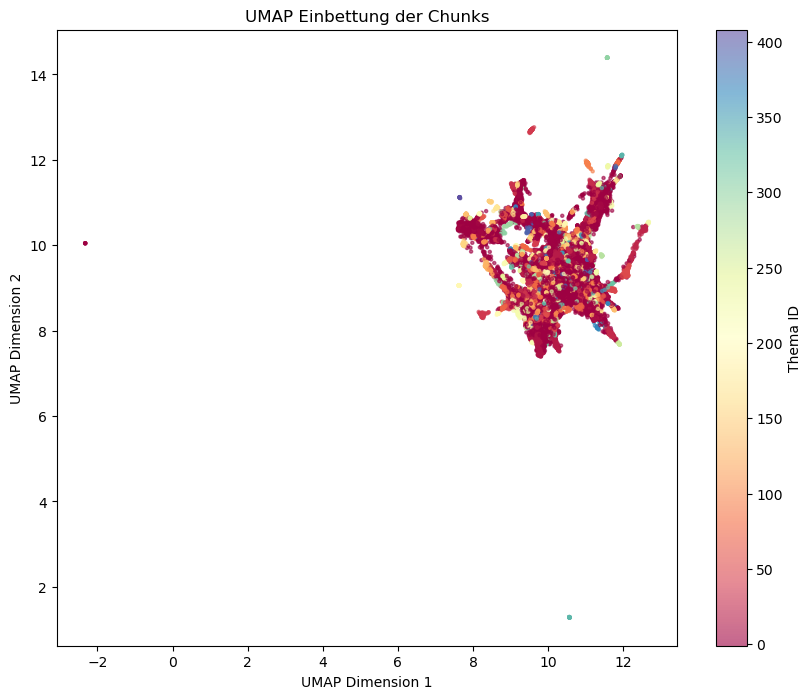

In [58]:
import matplotlib.pyplot as plt

# 1. Die bereits berechneten 2D-Koordinaten direkt aus BERTopic ziehen
umap_embeddings = topic_model.umap_model.embedding_

# 2. Scatterplot erstellen (Variablen an deinen Code angepasst)
plt.figure(figsize=(10, 8))
plt.scatter(
    umap_embeddings[:, 0], 
    umap_embeddings[:, 1], 
    c=topics,          # Deine Variable aus fit_transform
    cmap='Spectral', 
    s=5, 
    alpha=0.6
)
plt.colorbar(label='Thema ID')
plt.title('UMAP Einbettung der Chunks')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

plt.savefig("umap_original_einbettung_chunks.jpg", format="jpg", dpi=150, bbox_inches='tight')

plt.show()

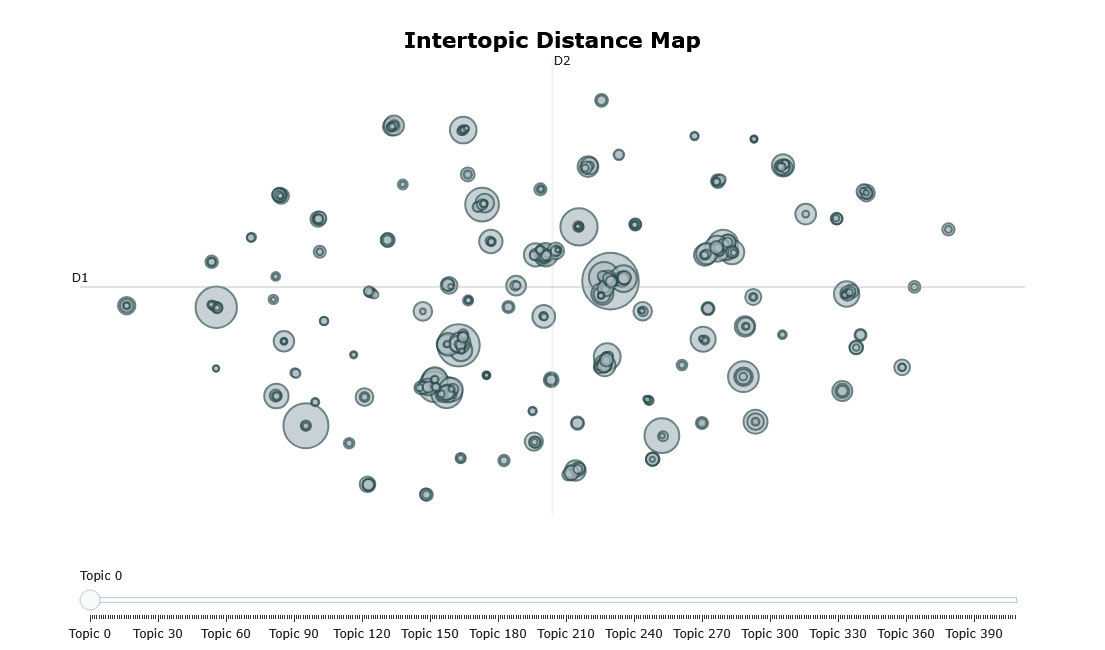

In [59]:
# document_embeddings = embedding_model.encode(alle_chunks, show_progress_bar=True)
# Das Objekt in einer Variable speichern und .show() anhängen
fig1 = topic_model.visualize_topics()
fig1.write_html("topics_visualisierung.html")
fig1.show()

In [60]:
#fig2 = topic_model.visualize_documents(alle_chunks, embeddings=document_embeddings)
#fig2.write_html("topics_visualisierung_2.html")
#fig2.show()

In [61]:
topic_info = topic_model.get_topic_info()
topic_info.head(25)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2111,-1_türkei_wohnung_petition_armut,"[türkei, wohnung, petition, armut, frankreich,...","[. Da steht auf der einen Seite das, was wenn ..."
1,0,1872,0_rezession_wirtschaftspolitik_wirtschaftswach...,"[rezession, wirtschaftspolitik, wirtschaftswac...",[. Aber der Befund nach drei Jahren Bundeskanz...
2,1,1001,1_mietpreisbremse_wohnungen_wohnraum_wohnen,"[mietpreisbremse, wohnungen, wohnraum, wohnen,...","[. wir können uns heute darüber streiten, welc..."
3,2,1182,2_israel_hamas_antisemitismus_juden,"[israel, hamas, antisemitismus, juden, israels...",[Die Bilder auf unseren Straßen ich füge hinzu...
4,3,665,3_kindergrundsicherung_gewalt frauen_elterngel...,"[kindergrundsicherung, gewalt frauen, elternge...","[. Deshalb erarbeite ich gerade ein Gesetz, da..."
5,4,1038,4_migrationspolitik_grenzkontrollen_zurückweis...,"[migrationspolitik, grenzkontrollen, zurückwei...","[Kollegin, ich muss jetzt schon noch mal darau..."
6,5,810,5_landwirtschaft_landwirte_bauern_ernährung,"[landwirtschaft, landwirte, bauern, ernährung,...",[Landwirte und Winzer sind Unternehmer. Wir we...
7,6,708,6_impfpflicht_impfung_impfen_allgemeine impfpf...,"[impfpflicht, impfung, impfen, allgemeine impf...",[. März 2022 zum vorliegenden Gesetzentwurf im...
8,7,529,7_soldaten_sondervermögen_nato_verteidigung,"[soldaten, sondervermögen, nato, verteidigung,...","[. Sie ermöglicht es, in die Verteidigung der ..."
9,8,540,8_bürokratieabbau_one_normenkontrollrat_europarat,"[bürokratieabbau, one, normenkontrollrat, euro...","[Mal hü, mal hott nach diesem Prinzip agiert d..."


In [62]:
# Liste der Topic-IDs
gewuenschte_topics = [2, 7, 20]

# Filtert die Tabelle nach diesen IDs
neue_tabelle = topic_info[topic_info['Topic'].isin(gewuenschte_topics)]

# Zeigt das Ergebnis im Notebook an
neue_tabelle

,Topic,Count,Name,Representation,Representative_Docs
3,2,1182,2_israel_hamas_antisemitismus_juden,"[israel, hamas, antisemitismus, juden, israels...",[Die Bilder auf unseren Straßen ich füge hinzu...
8,7,529,7_soldaten_sondervermögen_nato_verteidigung,"[soldaten, sondervermögen, nato, verteidigung,...","[. Sie ermöglicht es, in die Verteidigung der ..."
21,20,288,20_polen_geflüchteten_ukrainer_ukrainerinnen,"[polen, geflüchteten, ukrainer, ukrainerinnen,...",[. Aber die Polen zählen beispielsweise auch d...


In [63]:
# in LaTex überführen

# Nur die Spalten 'Topic', 'Count' und 'Name' auswählen und in LaTeX überführen
latex_code = neue_tabelle[['Topic', 'Count', 'Name']].to_latex(
    index=False, 
    caption='themen_ausland', 
    label='tab:themen_ausland',
    column_format='ccc'
)

with open('themen_ausland.tex', 'w', encoding='utf-8') as f:
    f.write(latex_code)

In [64]:
# ============================================================
# die 13 vorgegebenen Hauptthemen
# ============================================================

print("Anzahl Hauptthemen:", len(topic_names))
print(topic_names)

# ============================================================
# das Embedding der 13 Hauptthemen, allerdings über die Seed-Wörter, nicht über die beschreibende Kategorie
# ============================================================

topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # alle wörter der jeweiligen Kategorie
    normalize_embeddings=True
)

Anzahl Hauptthemen: 13
['Innere Sicherheit', 'Asyl- und Zuwanderungspolitik', 'Gesellschafts- und Familienpolitik', 'Verkehrs- und Infrastrukturpolitik', 'Wohnungsmarktpolitik', 'Gesundheitspolitik', 'Bildungspolitik', 'Wirtschaft und Finanzen', 'Digitalisierung & Verwaltung', 'Außen-, Europa- und Verteidigungspolitik', 'Arbeitsmarktpolitik', 'Sozial- und Rentenpolitik', 'Umweltpolitik']


In [65]:
zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + ["01.01.-31.03.2022"] * CDU_1_chunks_len + ["01.10.-31.12.2023"] * CDU_2_chunks_len + ["01.10.-15.12.2024"] * CDU_3_chunks_len + ["01.01.-23.02.2025"] * CDU_4_chunks_len + ["01.05.-31.07.2025"] * CDU_5_chunks_len +
    ["WP"] * SPD_WP_chunks_len + ["01.01.-31.03.2022"] * SPD_1_chunks_len + ["01.10.-31.12.2023"] * SPD_2_chunks_len + ["01.10.-15.12.2024"] * SPD_3_chunks_len + ["01.01.-23.02.2025"] * SPD_4_chunks_len + ["01.05.-31.07.2025"] * SPD_5_chunks_len +
    ["WP"] * Grüne_WP_chunks_len + ["01.01.-31.03.2022"] * Grüne_1_chunks_len + ["01.10.-31.12.2023"] * Grüne_2_chunks_len + ["01.10.-15.12.2024"] * Grüne_3_chunks_len + ["01.01.-23.02.2025"] * Grüne_4_chunks_len + ["01.05.-31.07.2025"] * Grüne_5_chunks_len +
    ["WP"] * Linke_WP_chunks_len + ["01.01.-31.03.2022"] * Linke_1_chunks_len + ["01.10.-31.12.2023"] * Linke_2_chunks_len + ["01.10.-15.12.2024"] * Linke_3_chunks_len + ["01.01.-23.02.2025"] * Linke_4_chunks_len + ["01.05.-31.07.2025"] * Linke_5_chunks_len +
    ["WP"] * AfD_WP_chunks_len + ["01.01.-31.03.2022"] * AfD_1_chunks_len + ["01.10.-31.12.2023"] * AfD_2_chunks_len + ["01.10.-15.12.2024"] * AfD_3_chunks_len + ["01.01.-23.02.2025"] * AfD_4_chunks_len + ["01.05.-31.07.2025"] * AfD_5_chunks_len +
    ["WP"] * FDP_WP_chunks_len + ["01.01.-31.03.2022"] * FDP_1_chunks_len + ["01.10.-31.12.2023"] * FDP_2_chunks_len + ["01.10.-15.12.2024"] * FDP_3_chunks_len + ["01.01.-23.02.2025"] * FDP_4_chunks_len + ["01.05.-31.07.2025"] * 0
)

In [66]:
################################# ------   ENDE 1. Check BERTopic    -------- ##################################### 

In [67]:
##### 2. VERFAHREN  -> nachfolgender Code arbeitet mit allen > 44.834 chunks via cosine similarity
#####                  direkt 13 Hauptthemen

In [68]:
# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

Batches:   0%|          | 0/1402 [00:00<?, ?it/s]

In [69]:
zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

In [70]:
results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
results

,document,partei,gewicht,zeitraum,topic_id,similarity,topic
0,Unsere Bundesrepublik Deutschland ist eine gro...,CDU/CSU,1.96,WP,7,0.459775,Wirtschaft und Finanzen
1,Die vergangenen Jahre zeichnen leider ein ande...,CDU/CSU,1.2,WP,7,0.479990,Wirtschaft und Finanzen
2,Zugleich erleben wir Herausforderungen histori...,CDU/CSU,1.12,WP,8,0.467143,Digitalisierung & Verwaltung
3,"Wir wissen aber auch: Deutschland hat alles, u...",CDU/CSU,1.79,WP,-1,0.365665,NaN
4,Diese Kraft werden wir freisetzen. Dafür brauc...,CDU/CSU,1.35,WP,7,0.425959,Wirtschaft und Finanzen
...,...,...,...,...,...,...,...
44829,. Bei der Zurückweisung von Menschen ohne Einr...,FDP,1,D,1,0.644325,Asyl- und Zuwanderungspolitik
44830,". Dieses Signal braucht unser Land dringend, w...",FDP,1,D,1,0.447226,Asyl- und Zuwanderungspolitik
44831,Den heute von der CDUCSU-Bundestagsfraktion ei...,FDP,1,D,1,0.478522,Asyl- und Zuwanderungspolitik
44832,. Ich möchte an dieser Stelle jedoch auch beto...,FDP,1,D,1,0.485045,Asyl- und Zuwanderungspolitik


In [71]:
# Zählt alle Zeilen, bei denen die topic_id gleich -1 ist
anzahl_outlier = (results["topic_id"] == -1).sum()

anzahl_alle_chunks = len(alle_chunks)
anzahl_outlier_bertopic = sum(t == -1 for t in topics_original)
print(f"Anzahl Dokumente im Datensatz: {anzahl_alle_chunks}")
print(f"Anzahl aller Outlier im 1. Verfahren VOR 'reduce_outliers: {anzahl_outlier_bertopic}")
print(f"Anzahl aller Outlier im 2. Verahren: {anzahl_outlier}")

Anzahl Dokumente im Datensatz: 44834
Anzahl aller Outlier im 1. Verfahren VOR 'reduce_outliers: 15748
Anzahl aller Outlier im 2. Verahren: 9061


In [72]:
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

In [73]:
# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

distribution

,partei,zeitraum_name,topic,anteil
0,AfD,01.01.-23.02.2025,Arbeitsmarktpolitik,0.943396
1,AfD,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,18.867925
2,AfD,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",9.433962
3,AfD,01.01.-23.02.2025,Bildungspolitik,0.471698
4,AfD,01.01.-23.02.2025,Digitalisierung & Verwaltung,2.830189
...,...,...,...,...
421,SPD,Wahlprogramm,Sozial- und Rentenpolitik,7.970014
422,SPD,Wahlprogramm,Umweltpolitik,9.756164
423,SPD,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,4.660226
424,SPD,Wahlprogramm,Wirtschaft und Finanzen,15.593624


In [74]:
cdu_data = distribution[distribution['partei'] == 'CDU/CSU']  # ok
spd_data = distribution[distribution['partei'] == 'SPD']
linke_data = distribution[distribution['partei'] == 'Linke']
grüne_data = distribution[distribution['partei'] == 'Grüne']  # ok
fdp_data = distribution[distribution['partei'] == 'FDP']
afd_data = distribution[distribution['partei'] == 'AfD']  # ok

In [75]:
distribution_matrix = (
    distribution
    .pivot_table(
        index="topic",
        columns=["partei", "zeitraum_name"],
        values="anteil",
        fill_value=0
    )
)

distribution_matrix

partei                                                 AfD                    \
zeitraum_name                            01.01.-23.02.2025 01.01.-31.03.2022   
topic                                                                          
Arbeitsmarktpolitik                               0.943396          5.526316   
Asyl- und Zuwanderungspolitik                    18.867925          1.578947   
Außen-, Europa- und Verteidigungspolitik          9.433962         13.684211   
Bildungspolitik                                   0.471698          5.526316   
Digitalisierung & Verwaltung                      2.830189          5.000000   
Gesellschafts- und Familienpolitik               14.150943          5.789474   
Gesundheitspolitik                                0.943396          6.578947   
Innere Sicherheit                                20.283019          9.473684   
Sozial- und Rentenpolitik                         2.830189          8.947368   
Umweltpolitik                                     6.603774          3.157895   
Verkehrs- und Infrastrukturpolitik                3.301887          4.736842   
Wirtschaft und Finanzen                          16.981132         21.315789   
Wohnungsmarktpolitik                              2.358491          8.684211   

partei                                                                        \
zeitraum_name                            01.05.-31.07.2025 01.10.-15.12.2024   
topic                                                                          
Arbeitsmarktpolitik                               3.085150          4.312668   
Asyl- und Zuwanderungspolitik                     9.214315          7.142857   
Außen-, Europa- und Verteidigungspolitik         10.530646          8.760108   
Bildungspolitik                                   2.879473          1.617251   
Digitalisierung & Verwaltung                      7.568902          9.568733   
Gesellschafts- und Familienpolitik                6.375977          9.164420   
Gesundheitspolitik                                3.825586         10.646900   
Innere Sicherheit                                 8.638420          8.355795   
Sozial- und Rentenpolitik                         6.005759          7.008086   
Umweltpolitik                                     9.132044          5.256065   
Verkehrs- und Infrastrukturpolitik                4.483752          3.773585   
Wirtschaft und Finanzen                          19.827232         19.137466   
Wohnungsmarktpolitik                              8.432744          5.256065   

partei                                                                   \
zeitraum_name                            01.10.-31.12.2023 Wahlprogramm   
topic                                                                     
Arbeitsmarktpolitik                               5.987055     8.107218   
Asyl- und Zuwanderungspolitik                     7.443366     3.500395   
Außen-, Europa- und Verteidigungspolitik          3.721683     6.949750   
Bildungspolitik                                   4.530744     5.064542   
Digitalisierung & Verwaltung                     10.841424     6.571062   
Gesellschafts- und Familienpolitik                8.414239     8.354189   
Gesundheitspolitik                                4.368932     6.292808   
Innere Sicherheit                                 9.385113     4.572247   
Sozial- und Rentenpolitik                         7.766990     5.067835   
Umweltpolitik                                     5.339806    12.248090   
Verkehrs- und Infrastrukturpolitik                5.339806     4.292347   
Wirtschaft und Finanzen                          20.550162    21.023775   
Wohnungsmarktpolitik                              6.310680     7.955743   

partei                                             CDU/CSU                    \
zeitraum_name                            01.01.-23.02.2025 01.01.-31.03.2022   
topic                                                                        

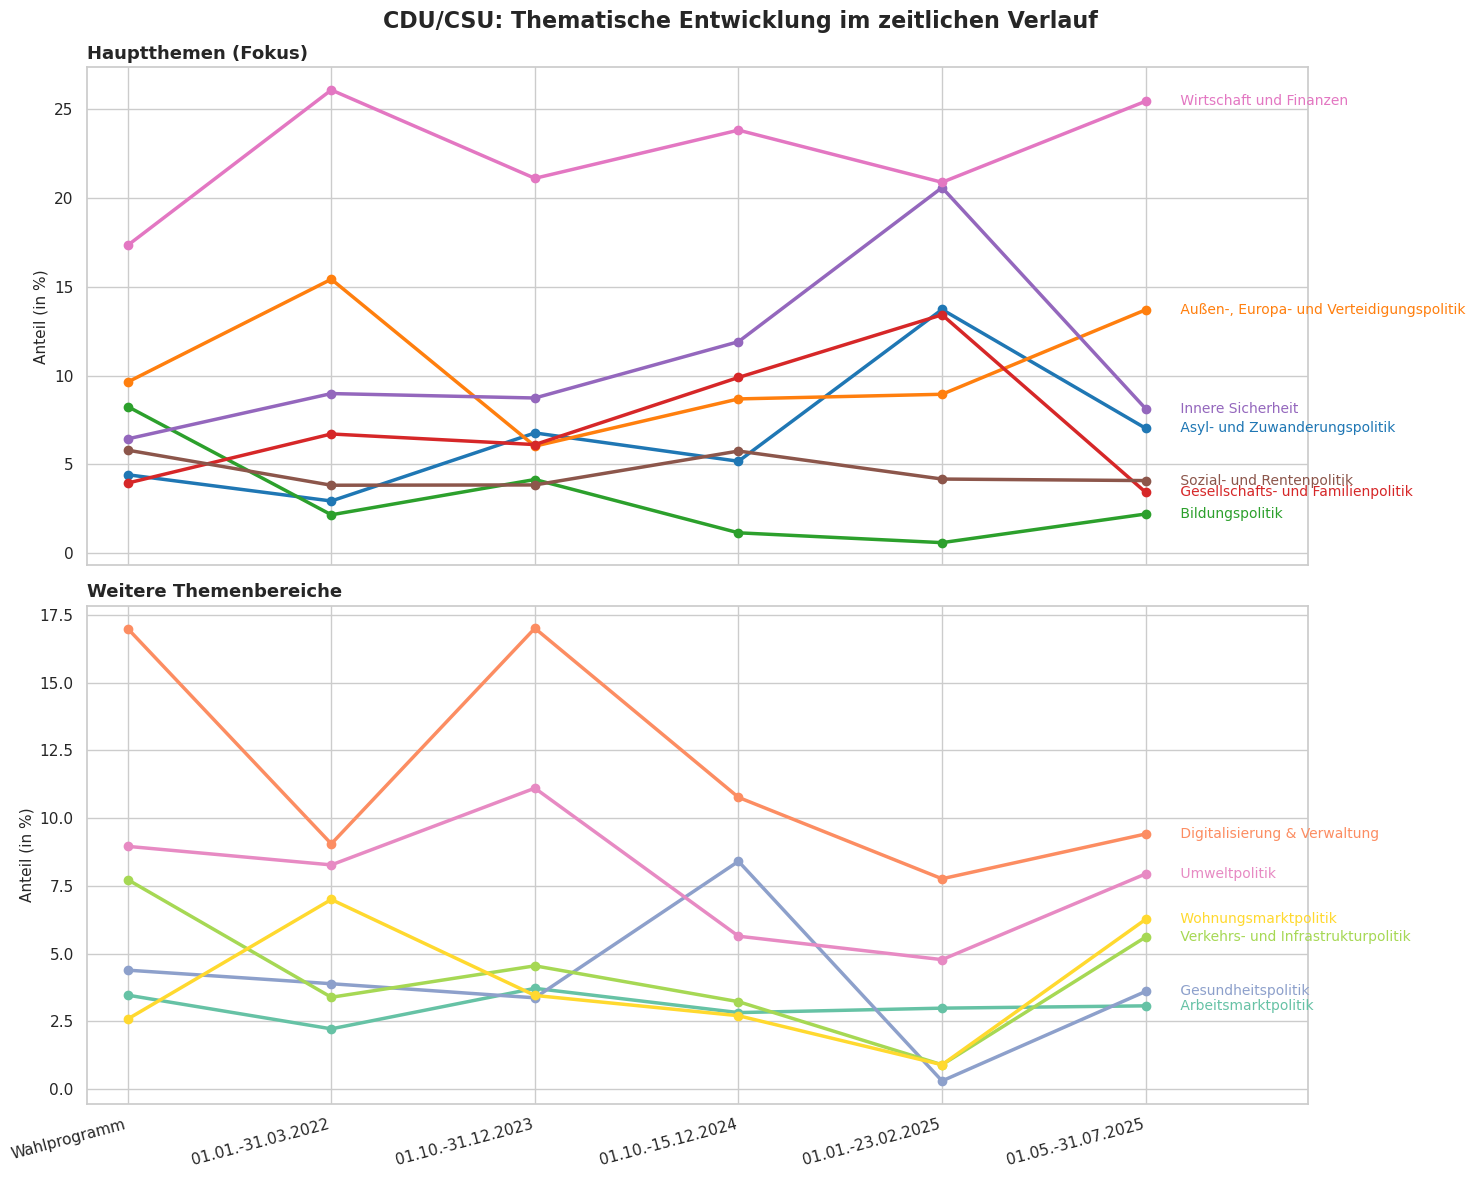

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('cdu_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [77]:
cdu_data = cdu_data
cdu_data

,partei,zeitraum_name,topic,anteil
78,CDU/CSU,01.01.-23.02.2025,Arbeitsmarktpolitik,2.985075
79,CDU/CSU,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,13.731343
80,CDU/CSU,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",8.955224
81,CDU/CSU,01.01.-23.02.2025,Bildungspolitik,0.597015
82,CDU/CSU,01.01.-23.02.2025,Digitalisierung & Verwaltung,7.761194
...,...,...,...,...
151,CDU/CSU,Wahlprogramm,Sozial- und Rentenpolitik,5.807363
152,CDU/CSU,Wahlprogramm,Umweltpolitik,8.957840
153,CDU/CSU,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,7.728967
154,CDU/CSU,Wahlprogramm,Wirtschaft und Finanzen,17.347199


In [78]:
cdu_data[cdu_data['zeitraum_name'] == 'Wahlprogramm'][['topic', 'anteil']]
cdu_data

,partei,zeitraum_name,topic,anteil
78,CDU/CSU,01.01.-23.02.2025,Arbeitsmarktpolitik,2.985075
79,CDU/CSU,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,13.731343
80,CDU/CSU,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",8.955224
81,CDU/CSU,01.01.-23.02.2025,Bildungspolitik,0.597015
82,CDU/CSU,01.01.-23.02.2025,Digitalisierung & Verwaltung,7.761194
...,...,...,...,...
151,CDU/CSU,Wahlprogramm,Sozial- und Rentenpolitik,5.807363
152,CDU/CSU,Wahlprogramm,Umweltpolitik,8.957840
153,CDU/CSU,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,7.728967
154,CDU/CSU,Wahlprogramm,Wirtschaft und Finanzen,17.347199


In [79]:
# Die Liste muss genau 13 Einträge haben
seiten_liste = [8, 5, 5, 9, 3, 5, 5, 4, 8, 2, 2, 3, 1]
seitenzahlen = ["13-21", "73-78", "19-24", "45-54", "70-73", "62-67", "36-40 und 44", "29-33", "54-62", "11-13", "40-42", "67-70", "70-73"]
eindeutigkeit = ["-", "-", "x", "x", "-", "x", "x", "x", "-", "x", "x", "-", "-"]
seitenumfang = 67
visueller_anteil = [seiten_liste[0]/seitenumfang*100, seiten_liste[1]/seitenumfang*100, seiten_liste[2]/seitenumfang*100, seiten_liste[3]/seitenumfang*100, seiten_liste[4]/seitenumfang*100, seiten_liste[5]/seitenumfang*100, seiten_liste[6]/seitenumfang*100, seiten_liste[7]/seitenumfang*100, seiten_liste[8]/seitenumfang*100, seiten_liste[9]/seitenumfang*100, seiten_liste[10]/seitenumfang*100, seiten_liste[11]/seitenumfang*100, seiten_liste[12]/seitenumfang*100]
cdu_data_v2 = cdu_data[cdu_data['zeitraum_name'] == 'Wahlprogramm'].copy()
cdu_data_v2['Seitenzahl'] = seiten_liste
cdu_data_v2['Seitenzahlen'] = seitenzahlen
cdu_data_v2['Klar_Abgrenzbar'] = eindeutigkeit
cdu_data_v2['Seitenanteil'] = visueller_anteil
cdu_data_v2['Seitenanteil'] = cdu_data_v2['Seitenanteil'].round(1)
cdu_data_v2['Abweichung_%'] = (((cdu_data_v2['Seitenanteil'] - cdu_data_v2['anteil']) / cdu_data_v2['anteil']) * 100).round(1)
cdu_data_v2 = cdu_data_v2.drop(columns=['partei', 'zeitraum_name'])
cdu_data_v2 = cdu_data_v2.set_index('topic')
cdu_data_v2

,anteil,Seitenzahl,Seitenzahlen,Klar_Abgrenzbar,Seitenanteil,Abweichung_%
topic,,,,,,
Arbeitsmarktpolitik,3.465355,8,13-21,-,11.9,243.4
Asyl- und Zuwanderungspolitik,4.421902,5,73-78,-,7.5,69.6
"Außen-, Europa- und Verteidigungspolitik",9.643763,5,19-24,x,7.5,-22.2
Bildungspolitik,8.261706,9,45-54,x,13.4,62.2
Digitalisierung & Verwaltung,16.996579,3,70-73,-,4.5,-73.5
Gesellschafts- und Familienpolitik,3.955543,5,62-67,x,7.5,89.6
Gesundheitspolitik,4.387861,5,36-40 und 44,x,7.5,70.9
Innere Sicherheit,6.442224,4,29-33,x,6.0,-6.9
Sozial- und Rentenpolitik,5.807363,8,54-62,-,11.9,104.9


In [80]:
# in LaTex überführen

latex_code = cdu_data_v2.to_latex(index=False, caption='abgleich_wp_cdu', label='tab:abgleich_wp_cdu',column_format='c|c|c|c|c|c|c')
with open('tabelle_abgleich_wp_cdu.tex', 'w') as f:
    f.write(latex_code)

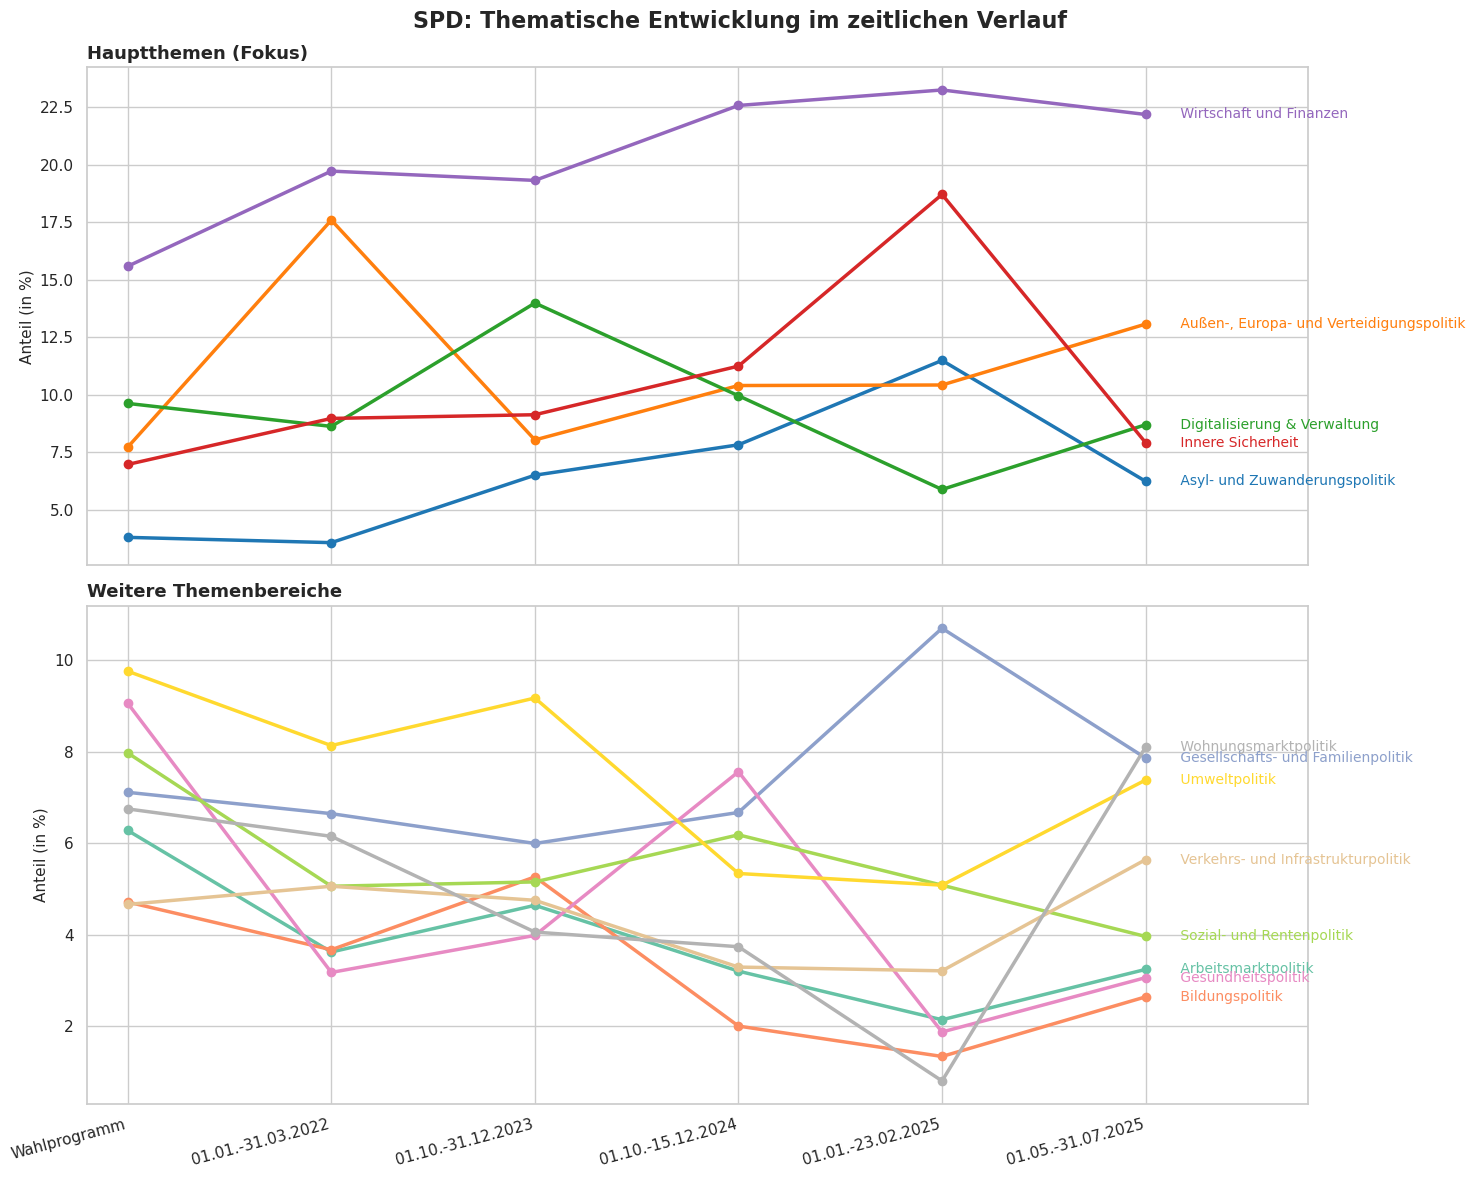

In [81]:
# 1. Daten gezielt für die CDU/CSU filtern
spd_data = distribution[distribution["partei"] == "SPD"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
spd_data = spd_data[spd_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = spd_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Digitalisierung & Verwaltung",
    "Außen-, Europa- und Verteidigungspolitik",
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("SPD: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('spd_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [82]:
spd_data= spd_data
spd_data

,partei,zeitraum_name,topic,anteil
348,SPD,01.01.-23.02.2025,Arbeitsmarktpolitik,2.139037
349,SPD,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,11.497326
350,SPD,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",10.427807
351,SPD,01.01.-23.02.2025,Bildungspolitik,1.336898
352,SPD,01.01.-23.02.2025,Digitalisierung & Verwaltung,5.882353
...,...,...,...,...
421,SPD,Wahlprogramm,Sozial- und Rentenpolitik,7.970014
422,SPD,Wahlprogramm,Umweltpolitik,9.756164
423,SPD,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,4.660226
424,SPD,Wahlprogramm,Wirtschaft und Finanzen,15.593624


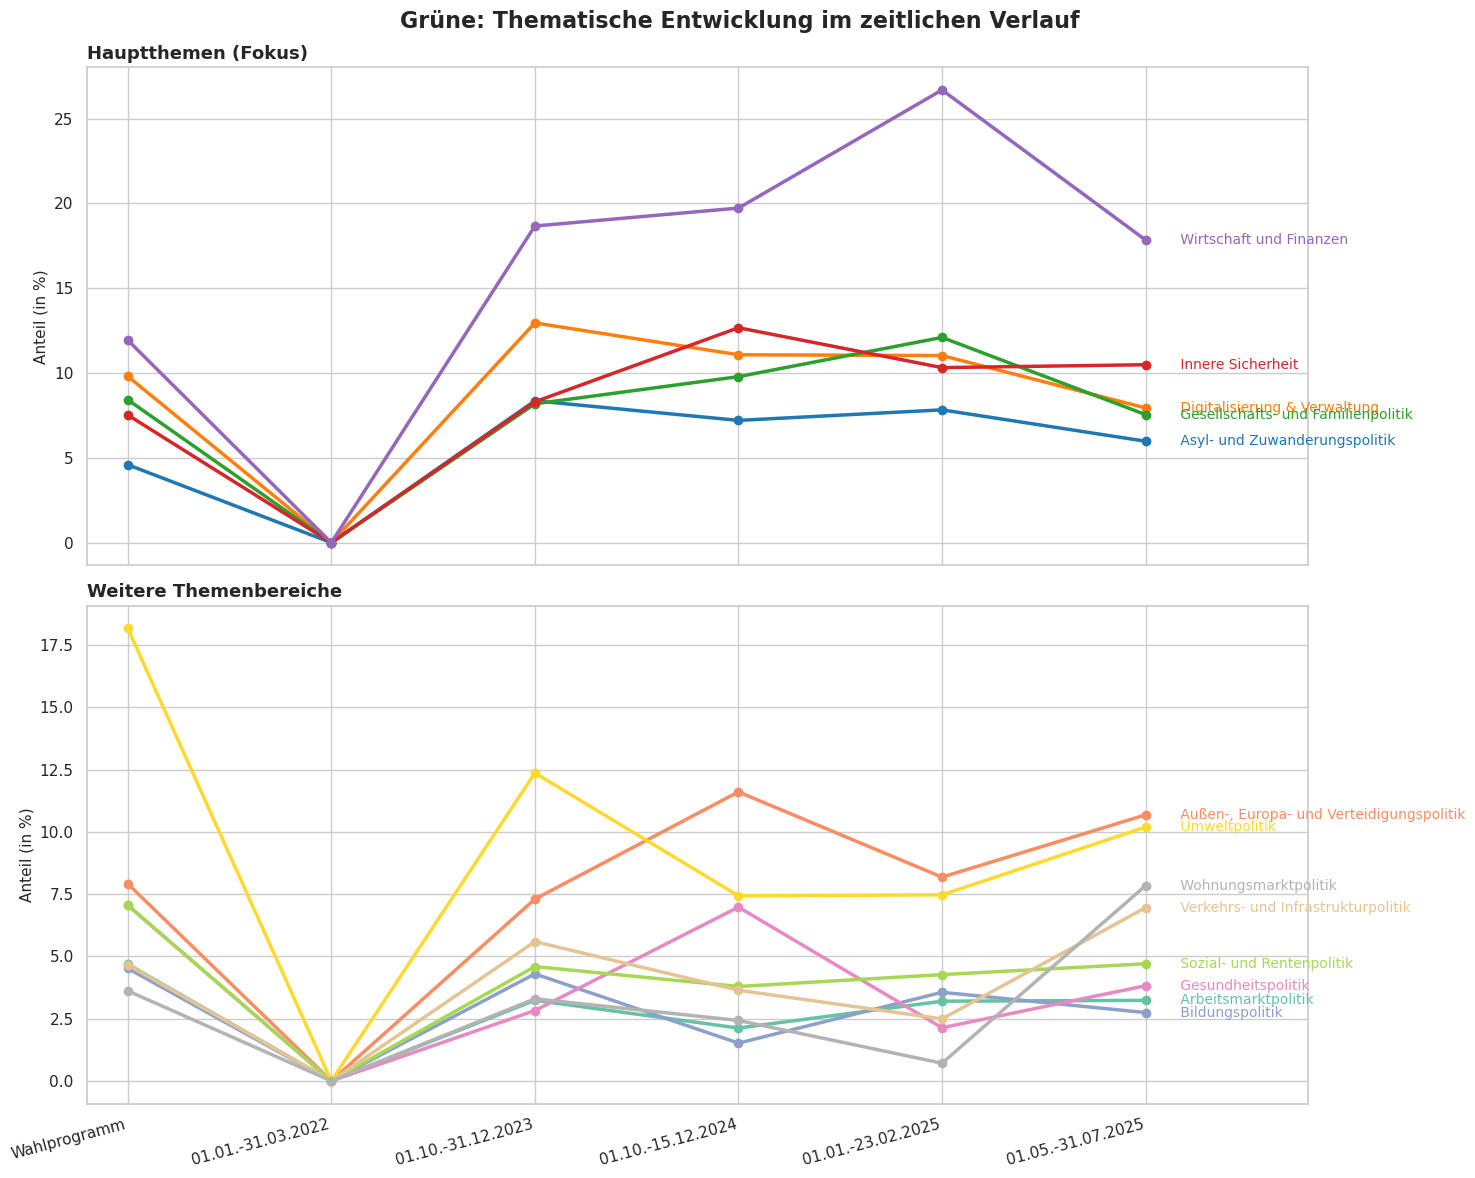

In [83]:
# 1. Daten gezielt für die Grüne filtern
grüne_data = distribution[distribution["partei"] == "Grüne"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
grüne_data = grüne_data[grüne_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = grüne_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Digitalisierung & Verwaltung",
    "Gesellschafts- und Familienpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("Grüne: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('Grüne_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [84]:
grüne_data = grüne_data
grüne_data

,partei,zeitraum_name,topic,anteil
219,Grüne,01.01.-23.02.2025,Arbeitsmarktpolitik,3.202847
220,Grüne,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,7.829181
221,Grüne,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",8.185053
222,Grüne,01.01.-23.02.2025,Bildungspolitik,3.558719
223,Grüne,01.01.-23.02.2025,Digitalisierung & Verwaltung,11.032028
...,...,...,...,...
292,Grüne,Wahlprogramm,Sozial- und Rentenpolitik,7.063375
293,Grüne,Wahlprogramm,Umweltpolitik,18.180495
294,Grüne,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,4.661079
295,Grüne,Wahlprogramm,Wirtschaft und Finanzen,11.940764


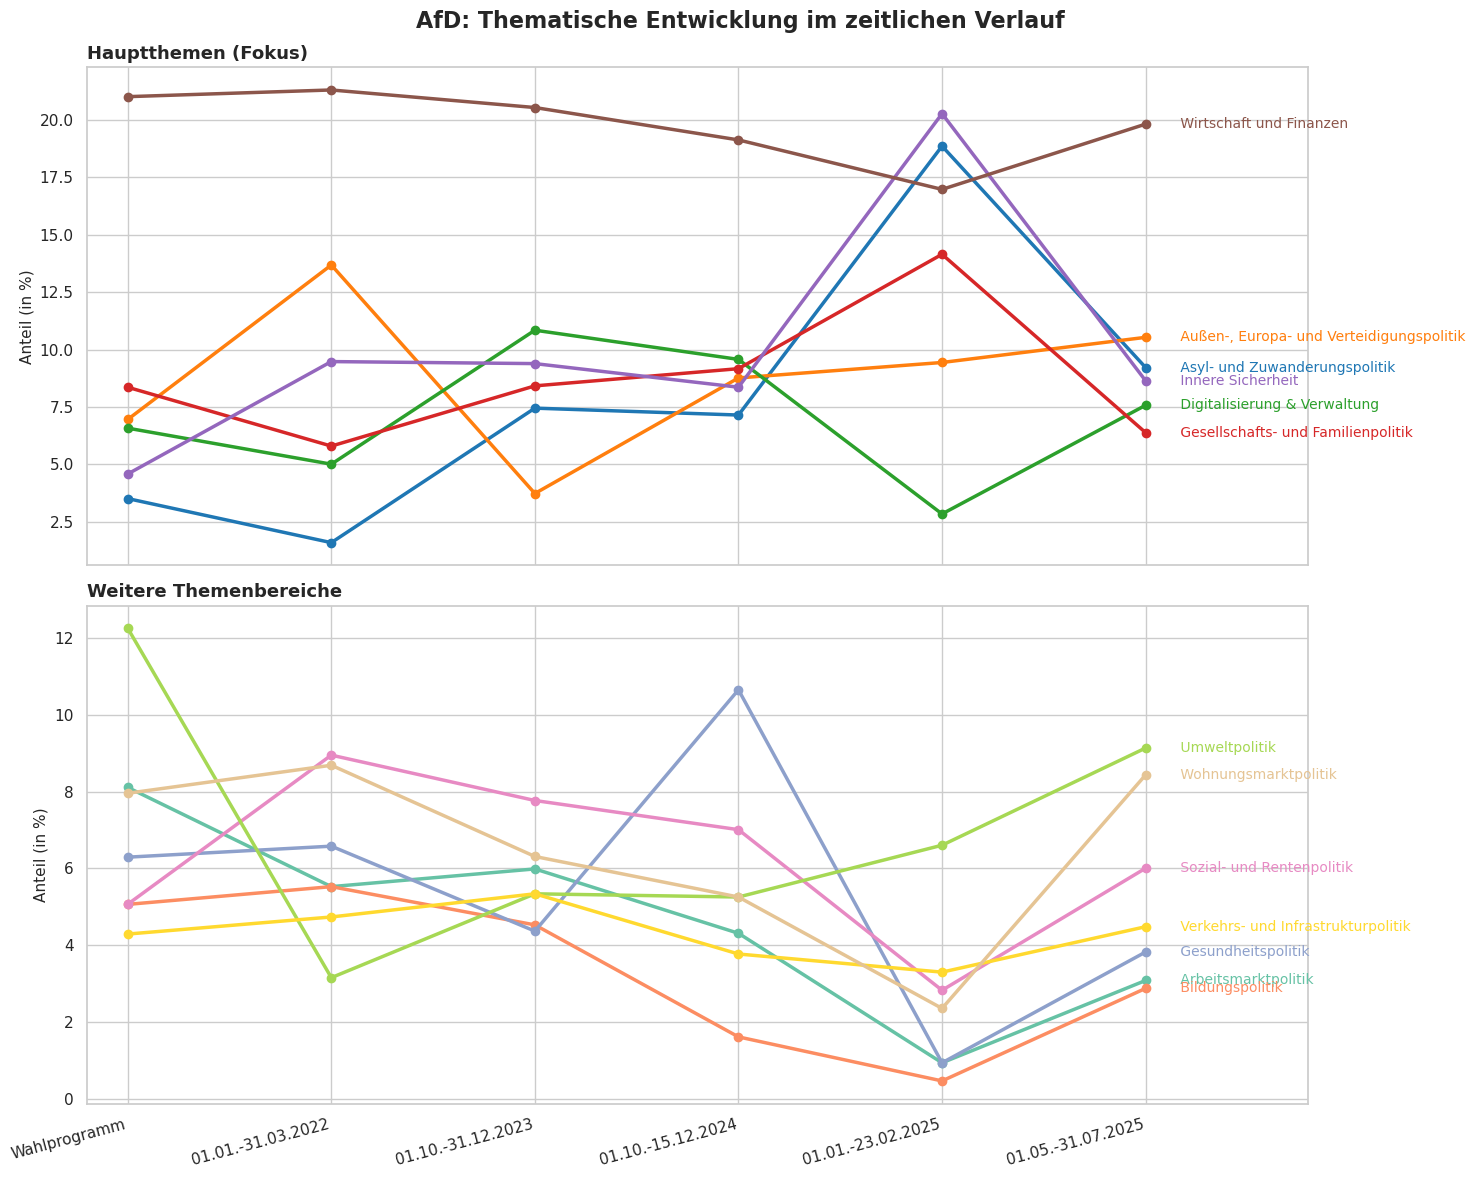

In [85]:
# 1. Daten gezielt für die AfD filtern
afd_data = distribution[distribution["partei"] == "AfD"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
afd_data = afd_data[afd_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = afd_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Digitalisierung & Verwaltung",
    "Außen-, Europa- und Verteidigungspolitik",
    "Gesellschafts- und Familienpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("AfD: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('AfD_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [86]:
afd_data = afd_data
afd_data

,partei,zeitraum_name,topic,anteil
0,AfD,01.01.-23.02.2025,Arbeitsmarktpolitik,0.943396
1,AfD,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,18.867925
2,AfD,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",9.433962
3,AfD,01.01.-23.02.2025,Bildungspolitik,0.471698
4,AfD,01.01.-23.02.2025,Digitalisierung & Verwaltung,2.830189
...,...,...,...,...
73,AfD,Wahlprogramm,Sozial- und Rentenpolitik,5.067835
74,AfD,Wahlprogramm,Umweltpolitik,12.248090
75,AfD,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,4.292347
76,AfD,Wahlprogramm,Wirtschaft und Finanzen,21.023775


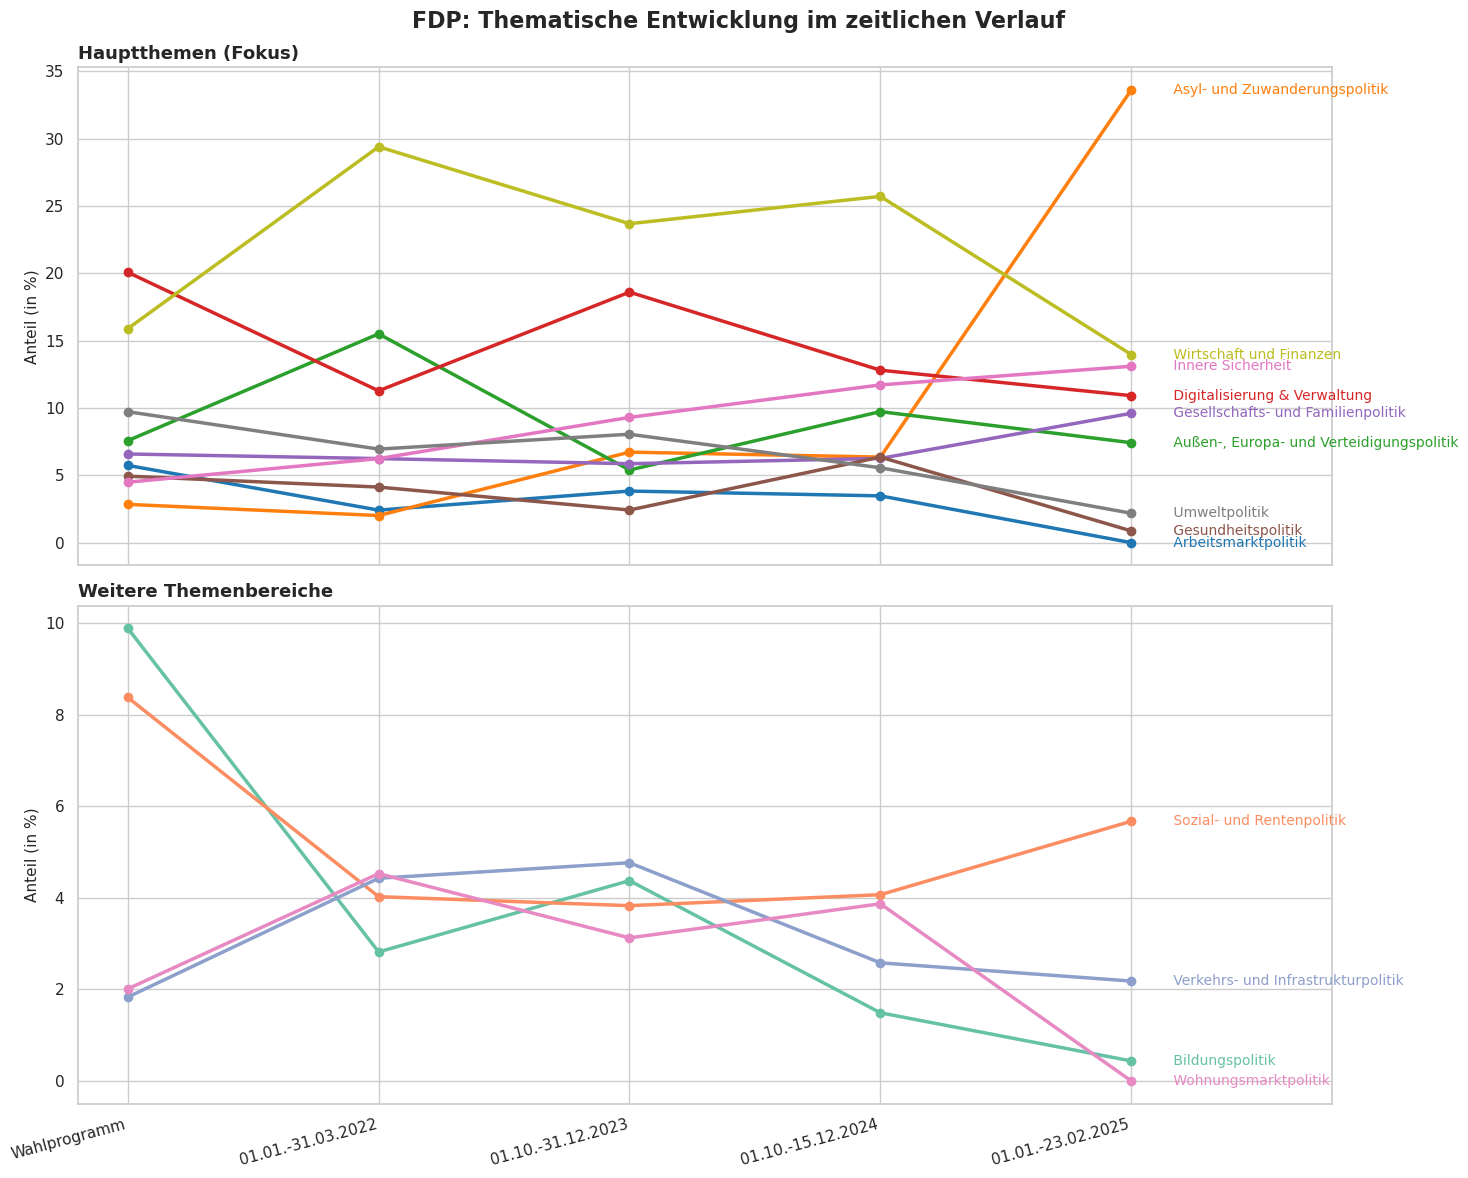

In [87]:
# 1. Daten gezielt für die FDP filtern
fdp_data = distribution[distribution["partei"] == "FDP"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
fdp_data = fdp_data[fdp_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = fdp_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Digitalisierung & Verwaltung",
    "Arbeitsmarktpolitik",
    "Gesundheitspolitik",
    "Umweltpolitik",
    "Außen-, Europa- und Verteidigungspolitik",
    "Gesellschafts- und Familienpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("FDP: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('FDP_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [88]:
fdp_data = fdp_data
fdp_data

,partei,zeitraum_name,topic,anteil
156,FDP,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,33.624454
157,FDP,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",7.423581
158,FDP,01.01.-23.02.2025,Bildungspolitik,0.436681
159,FDP,01.01.-23.02.2025,Digitalisierung & Verwaltung,10.917031
160,FDP,01.01.-23.02.2025,Gesellschafts- und Familienpolitik,9.606987
...,...,...,...,...
214,FDP,Wahlprogramm,Sozial- und Rentenpolitik,8.384378
215,FDP,Wahlprogramm,Umweltpolitik,9.727452
216,FDP,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,1.831975
217,FDP,Wahlprogramm,Wirtschaft und Finanzen,15.892105


In [89]:
# bis zu getesteten Chunk-Größen von 4800 Zeichen scheitert die Ergebnis-Findung für die Linke,
# daher läuft für sie ein Extra-Training mit chunks von 7.200 Zeichen, aus der dann die Grafik erstellt wird
# dies ist auch notwendig zur Ermittlung der Heatmap

In [119]:
# neuer Text-Split mit 7200 Zeichen
def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=7200,
        chunk_overlap=0,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

In [120]:
# bei Bedarf
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

In [121]:
# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

In [122]:
zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

In [123]:
embedding_model.encode_kwargs = {"task": "separation"}

In [124]:
# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

Batches:   0%|          | 0/371 [00:00<?, ?it/s]

In [125]:
print(len(alle_chunks))
print(len(zeitraum_labels))
print(len(partei_labels))
print(len(alle_anteil))
print(len(zeitraum_labels))
print(len(assigned_topics))

11849
11849
11849
11849
11849
11849


In [126]:
results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
results

,document,partei,gewicht,zeitraum,topic_id,similarity,topic
0,Unsere Bundesrepublik Deutschland ist eine gro...,CDU/CSU,1.96,WP,7,0.459711,Wirtschaft und Finanzen
1,Die vergangenen Jahre zeichnen leider ein ande...,CDU/CSU,1.2,WP,7,0.478983,Wirtschaft und Finanzen
2,Zugleich erleben wir Herausforderungen histori...,CDU/CSU,1.12,WP,8,0.467153,Digitalisierung & Verwaltung
3,"Wir wissen aber auch: Deutschland hat alles, u...",CDU/CSU,1.79,WP,-1,0.365665,NaN
4,Diese Kraft werden wir freisetzen. Dafür brauc...,CDU/CSU,1.35,WP,7,0.426013,Wirtschaft und Finanzen
...,...,...,...,...,...,...,...
11844,Das Messerattentat in Aschaffenburg hat unser ...,FDP,1,D,1,0.439644,Asyl- und Zuwanderungspolitik
11845,Die Migrationspolitik der Bundesrepublik Deuts...,FDP,1,D,1,0.561737,Asyl- und Zuwanderungspolitik
11846,Die Bundesrepublik Deutschland hat als einer d...,FDP,1,D,3,0.436852,Verkehrs- und Infrastrukturpolitik
11847,Erstens. In den letzten Jahren ist in Deutschl...,FDP,1,D,1,0.581329,Asyl- und Zuwanderungspolitik


In [127]:
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

In [128]:
# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

distribution

,partei,zeitraum_name,topic,anteil
0,AfD,01.01.-23.02.2025,Arbeitsmarktpolitik,9.090909
1,AfD,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,9.090909
2,AfD,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",9.090909
3,AfD,01.01.-23.02.2025,Gesellschafts- und Familienpolitik,18.181818
4,AfD,01.01.-23.02.2025,Innere Sicherheit,18.181818
...,...,...,...,...
415,SPD,Wahlprogramm,Sozial- und Rentenpolitik,7.950220
416,SPD,Wahlprogramm,Umweltpolitik,9.731933
417,SPD,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,4.648652
418,SPD,Wahlprogramm,Wirtschaft und Finanzen,15.741166


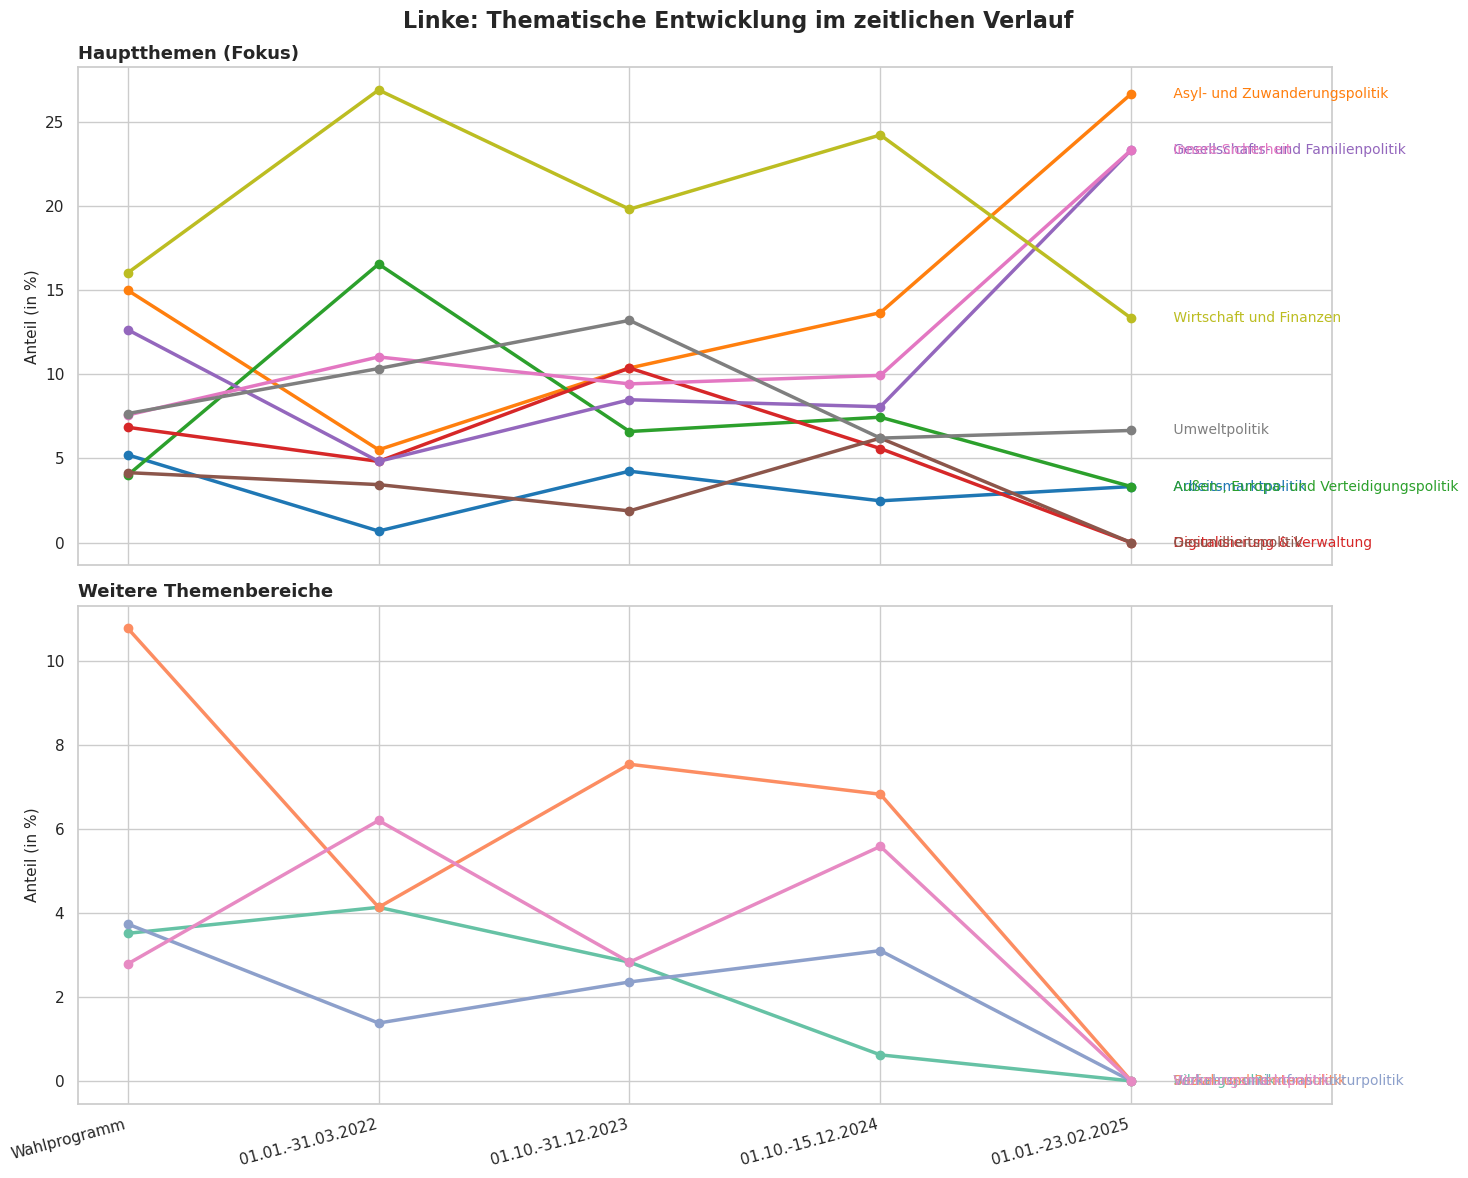

In [129]:
# 1. Daten gezielt für die Linke filtern
linke_data = distribution[distribution["partei"] == "Linke"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    #"01.05.-31.07.2025",
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
linke_data = linke_data[linke_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = linke_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Digitalisierung & Verwaltung",
    "Arbeitsmarktpolitik",
    "Gesundheitspolitik",
    "Umweltpolitik",
    "Außen-, Europa- und Verteidigungspolitik",
    "Gesellschafts- und Familienpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("Linke: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('Linke_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [130]:
linke_data = linke_data
linke_data

,partei,zeitraum_name,topic,anteil
285,Linke,01.01.-23.02.2025,Arbeitsmarktpolitik,3.333333
286,Linke,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,26.666667
287,Linke,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",3.333333
288,Linke,01.01.-23.02.2025,Gesellschafts- und Familienpolitik,23.333333
289,Linke,01.01.-23.02.2025,Innere Sicherheit,23.333333
290,Linke,01.01.-23.02.2025,Umweltpolitik,6.666667
291,Linke,01.01.-23.02.2025,Wirtschaft und Finanzen,13.333333
292,Linke,01.01.-31.03.2022,Arbeitsmarktpolitik,0.689655
293,Linke,01.01.-31.03.2022,Asyl- und Zuwanderungspolitik,5.517241
294,Linke,01.01.-31.03.2022,"Außen-, Europa- und Verteidigungspolitik",16.551724


In [131]:
# Das Dataframe in die Breite ziehen (Themen als Zeilen, Zeiträume als Spalten)
linke_wide = linke_data.pivot(index='topic', columns='zeitraum_name', values='anteil')

# Option: Index-Name entfernen für eine sauberere Anzeige
linke_wide.columns.name = None

# Daten anzeigen
linke_wide


,01.01.-23.02.2025,01.01.-31.03.2022,01.10.-15.12.2024,01.10.-31.12.2023,Wahlprogramm
topic,,,,,
Arbeitsmarktpolitik,3.333333,0.689655,2.484472,4.245283,5.216707
Asyl- und Zuwanderungspolitik,26.666667,5.517241,13.664596,10.377358,14.992767
"Außen-, Europa- und Verteidigungspolitik",3.333333,16.551724,7.453416,6.603774,4.008203
Bildungspolitik,NaN,4.137931,0.621118,2.830189,3.517478
Digitalisierung & Verwaltung,NaN,4.827586,5.590062,10.377358,6.853680
Gesellschafts- und Familienpolitik,23.333333,4.827586,8.074534,8.490566,12.650834
Gesundheitspolitik,NaN,3.448276,6.211180,1.886792,4.160182
Innere Sicherheit,23.333333,11.034483,9.937888,9.433962,7.582444
Sozial- und Rentenpolitik,NaN,4.137931,6.832298,7.547170,10.788640


In [132]:
################################# ------   ENDE 2. TEIL ZUORDNUNG COSINE SIMILARITY    -------- #####################################   

In [133]:
########## HEATMAP ############

In [134]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.spatial.distance import jensenshannon
import matplotlib.patches as patches

# 1. Ihre Liste der DataFrames
df_GESAMT_verlauf = [cdu_data, spd_data, afd_data, grüne_data, fdp_data, linke_data]

# Zuordnung der Namen in exakt derselben Reihenfolge wie in Ihrer Liste
partei_namen = ['CDU/CSU', 'SPD', 'AfD', 'Grüne', 'FDP', 'Linke']

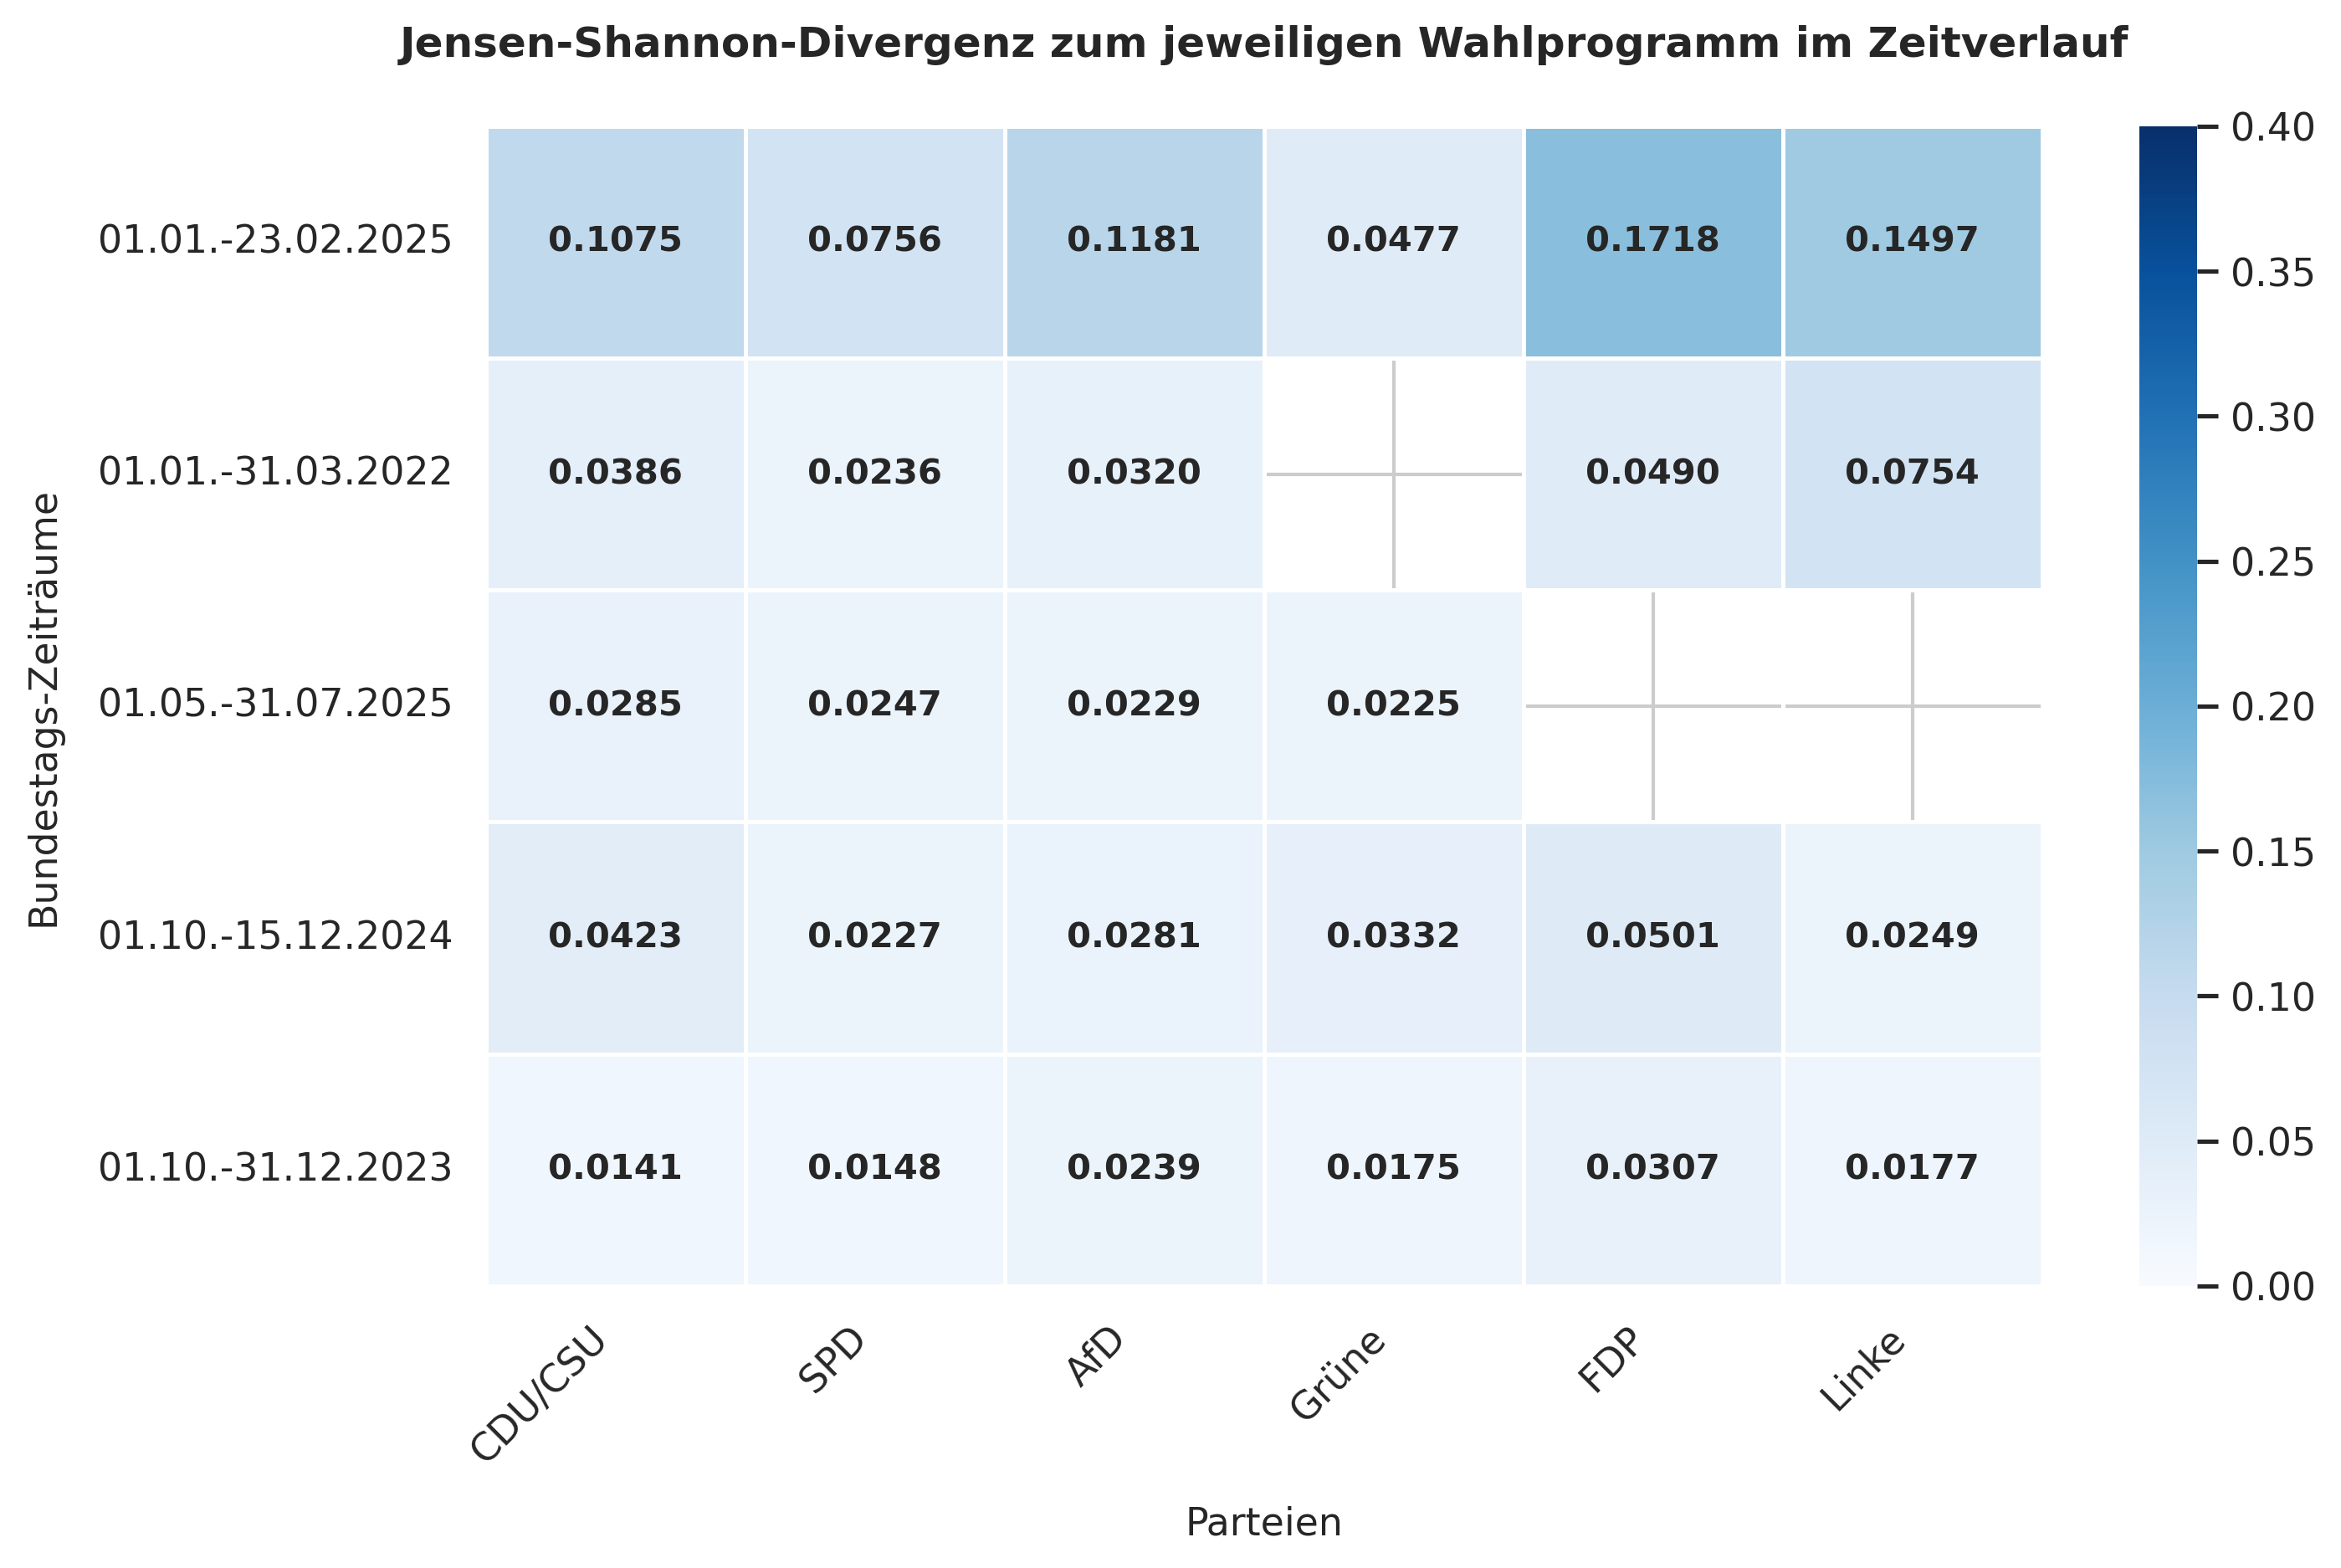

In [135]:
# 1. Eine leere Liste, um die JSD-Datenframes aller Parteien zu sammeln
matrix_listen = []

# Loop durch jede Partei, um die JSD-Spalten zu berechnen
for df_partei, name_partei in zip(df_GESAMT_verlauf, partei_namen):
    
    # --- NEU: Den spezifischen Zeitraum für "Linke" ausschließen ---
    if name_partei == "Linke":  # Passen Sie den Namen exakt an Ihre Liste an
        # Filtert den Zeitraum heraus, indem der Anteil auf NaN gesetzt wird
        df_partei.loc[df_partei['zeitraum_name'] == '01.05.-31.07.2025', 'anteil'] = np.nan
    
    # Pivot-Tabelle erstellen (jetzt mit dem gefilterten DataFrame)
    df_pivot = df_partei.pivot_table(
        index='zeitraum_name', 
        columns='topic', 
        values='anteil', 
        fill_value=0
    )
    
    # Zeilen auf Summe = 1 normalisieren (Wahrscheinlichkeitsverteilung)
    df_prob = df_pivot.div(df_pivot.sum(axis=1), axis=0)
    
    ref_label = 'Wahlprogramm'  
    if ref_label not in df_prob.index:
        print(f"Warnung: '{ref_label}' nicht gefunden für {name_partei}. Überspringe...")
        continue
        
    v_wahlprogramm = df_prob.loc[ref_label].values
    
    # JSD für jeden Zeitraum im Vergleich zum Wahlprogramm dieser Partei berechnen
    jsd_ergebnisse = {}
    for zeitraum in df_prob.index:
        v_zeitraum = df_prob.loc[zeitraum].values
        
        # JSD (quadriert für die echte Divergenz)
        jsd_value = jensenshannon(v_wahlprogramm, v_zeitraum) ** 2
        jsd_ergebnisse[zeitraum] = jsd_value
        
    # In DataFrame mit dem Parteinamen als Spaltenüberschrift wandeln
    df_jsd = pd.DataFrame.from_dict(jsd_ergebnisse, orient='index', columns=[name_partei])
    
    # Zur Liste hinzufügen
    matrix_listen.append(df_jsd)

# 2. ALLE PARTEIEN ZU EINER MATRIX ZUSAMMENFÜHREN (Verbindung über die Zeilen-Zeiträume)
df_jsd_matrix = pd.concat(matrix_listen, axis=1)

# 'Wahlprogramm' aus der Matrix löschen (ist überall 0)
df_jsd_matrix_plot = df_jsd_matrix.drop(index=ref_label, errors='ignore')

# 3. DIE GESAMT-MATRIX ALS HEATMAP PLOTTEN
# Die Breite (figsize) passt sich automatisch an die Anzahl Ihrer Parteien an
plt.figure(figsize=(10, 6), dpi=300) 

sns.heatmap(
    df_jsd_matrix_plot, 
    annot=True,          # Werte in den Kästchen anzeigen
    cmap='Blues',       # Farbverlauf von Gelb nach Rot
    vmin=0, vmax=0.4,    # Skala angepasst für optimale Farbunterschiede bei Politik-JSD
    fmt=".4f", 
    linewidths=.8,
    annot_kws={"size": 10, "weight": "bold"} # Gut lesbare Zahlen
)

# Titel und Achsenbeschriftung für die Masterarbeit
plt.title("Jensen-Shannon-Divergenz zum jeweiligen Wahlprogramm im Zeitverlauf", 
          fontsize=12, pad=20, fontweight='bold')
plt.xlabel("Parteien", fontsize=11, labelpad=10)
plt.ylabel("Bundestags-Zeiträume", fontsize=11, labelpad=10)

# Achsenbeschriftungen sauber ausrichten, damit nichts abgeschnitten wird
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

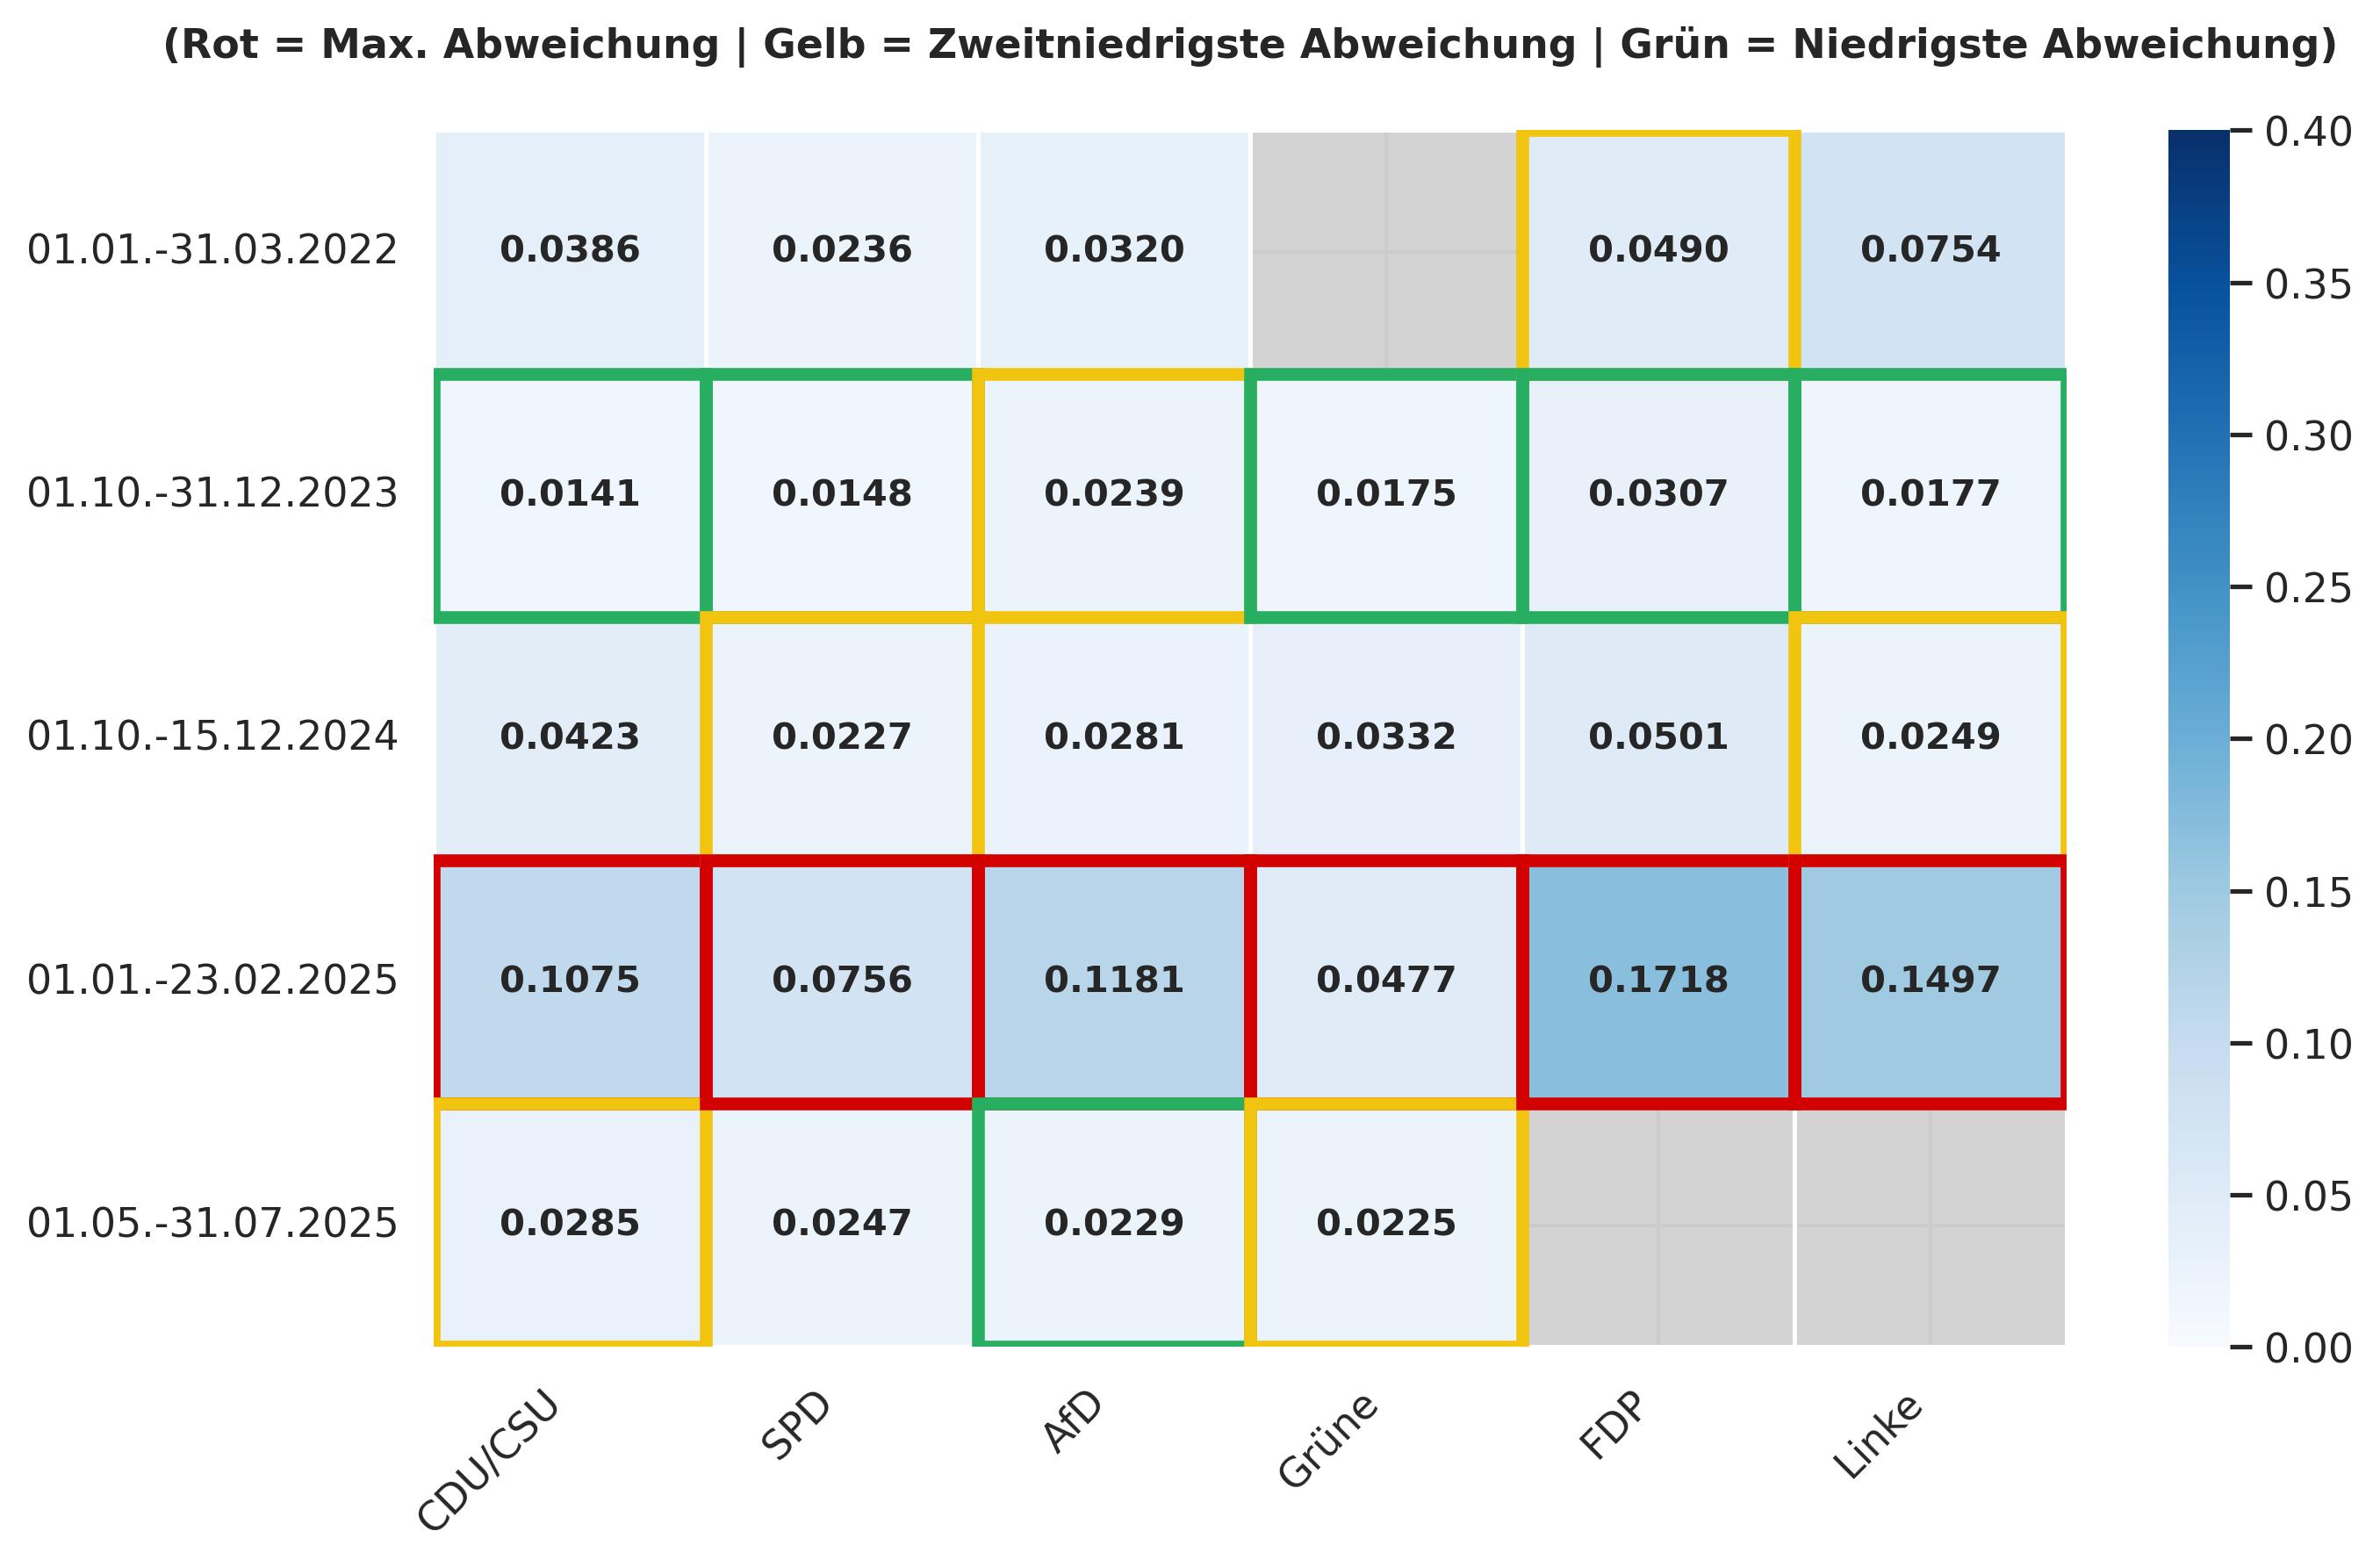

In [136]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# 1. Gewünschte Reihenfolge der Zeiträume exakt definieren
wunsch_reihenfolge = [
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 2. Die Matrix nach dieser Liste neu sortieren
df_jsd_matrix_plot = df_jsd_matrix_plot.reindex(wunsch_reihenfolge)

# 3. JETZT DIE HEATMAP PLOTTEN
fig, ax = plt.subplots(figsize=(10, 6), dpi=300) 

# Eine Maske für fehlende Werte (NaN) erstellen
leere_kacheln_maske = df_jsd_matrix_plot.isna()

sns.heatmap(
    df_jsd_matrix_plot, 
    annot=True,          
    cmap='Blues',       
    vmin=0, vmax=0.4,    
    fmt=".4f", 
    linewidths=.8,
    mask=leere_kacheln_maske, 
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

# Den Hintergrund des Diagramms auf Hellgrau setzen (für leere Kacheln)
ax.set_facecolor('#D3D3D3') 

# 4. JEDE SPALTE DURCHLAUFEN, MIN (GRÜN), ZWEITMIN (GELB) UND MAX (ROT) UMRANDEN
for col_idx, col_name in enumerate(df_jsd_matrix_plot.columns):
    spalte = df_jsd_matrix_plot[col_name]
    
    # Höchsten und niedrigsten Wert finden
    max_val = spalte.max()
    min_val = spalte.min()
    
    # NEU: Den exakt zweitniedrigsten Wert ermitteln (NaNs werden ignoriert)
    # nsmallest(2) holt die zwei kleinsten Werte, .iloc[-1] nimmt den zweiten davon.
    zweit_min_val = spalte.nsmallest(2).iloc[-1] if len(spalte.dropna()) >= 2 else None
    
    # Zeilen-Index durchlaufen und Rahmen zeichnen
    for row_idx, val in enumerate(spalte):
        if np.isnan(val):
            continue
            
        # ROTER RAHMEN FÜR DEN HÖCHSTEN WERT (Höchste Abweichung)
        if val == max_val:
            rect_max = patches.Rectangle(
                (col_idx, row_idx), 1, 1, fill=False,
                edgecolor='#D30000', linewidth=3.5, zorder=5
            )
            ax.add_patch(rect_max)
            
        # GRÜNER RAHMEN FÜR DEN NIEDRIGSTEN WERT (Niedrigste Abweichung)
        elif val == min_val:
            rect_min = patches.Rectangle(
                (col_idx, row_idx), 1, 1, fill=False,
                edgecolor='#27AE60', linewidth=3.5, zorder=5
            )
            ax.add_patch(rect_min)
            
        # NEU: GELBER RAHMEN FÜR DEN ZWEITNIEDRIGSTEN WERT (Zweitniedrigste Abweichung)
        elif zweit_min_val is not None and val == zweit_min_val:
            rect_zweit_min = patches.Rectangle(
                (col_idx, row_idx), 1, 1, fill=False,
                edgecolor='#F1C40F', linewidth=3.5, zorder=5 # Ein kräftiges "Akademiker-Gelb"
            )
            ax.add_patch(rect_zweit_min)

# Titel und Achsenbeschriftungen für Ihre Arbeit aktualisieren
plt.title("(Rot = Max. Abweichung | Gelb = Zweitniedrigste Abweichung | Grün = Niedrigste Abweichung)", 
          fontsize=11, pad=20, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 5. Als hochauflösendes JPG speichern
plt.savefig("js_divergenz_heatmap_highlights.jpg", bbox_inches='tight', dpi=300)

plt.show()

In [ ]:
# neue Heatmap, für alle Parteien bei 7.200-Segment-Größe

In [ ]:
# zunächst für alle Parteien die "x"-data-Variablen neu erstellen
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]
spd_data = distribution[distribution["partei"] == "SPD"].copy()
spd_data = spd_data[spd_data["zeitraum_name"].isin(zeitreihenfolge)]
grüne_data = distribution[distribution["partei"] == "Grüne"].copy()
grüne_data = grüne_data[grüne_data["zeitraum_name"].isin(zeitreihenfolge)]
afd_data = distribution[distribution["partei"] == "AfD"].copy()
afd_data = afd_data[afd_data["zeitraum_name"].isin(zeitreihenfolge)]
fdp_data = distribution[distribution["partei"] == "FDP"].copy()
fdp_data = fdp_data[fdp_data["zeitraum_name"].isin(zeitreihenfolge)]

In [ ]:
df_GESAMT_verlauf = [cdu_data, spd_data, afd_data, grüne_data, fdp_data, linke_data]

In [ ]:
# 1. Eine leere Liste, um die JSD-Datenframes aller Parteien zu sammeln
matrix_listen = []

# Loop durch jede Partei, um die JSD-Spalten zu berechnen
for df_partei, name_partei in zip(df_GESAMT_verlauf, partei_namen):
    
    # --- NEU: Den spezifischen Zeitraum für "Linke" ausschließen ---
    if name_partei == "Linke":  # Passen Sie den Namen exakt an Ihre Liste an
        # Filtert den Zeitraum heraus, indem der Anteil auf NaN gesetzt wird
        df_partei.loc[df_partei['zeitraum_name'] == '01.05.-31.07.2025', 'anteil'] = np.nan
    
    # Pivot-Tabelle erstellen (jetzt mit dem gefilterten DataFrame)
    df_pivot = df_partei.pivot_table(
        index='zeitraum_name', 
        columns='topic', 
        values='anteil', 
        fill_value=0
    )
    
    # Zeilen auf Summe = 1 normalisieren (Wahrscheinlichkeitsverteilung)
    df_prob = df_pivot.div(df_pivot.sum(axis=1), axis=0)
    
    ref_label = 'Wahlprogramm'  
    if ref_label not in df_prob.index:
        print(f"Warnung: '{ref_label}' nicht gefunden für {name_partei}. Überspringe...")
        continue
        
    v_wahlprogramm = df_prob.loc[ref_label].values
    
    # JSD für jeden Zeitraum im Vergleich zum Wahlprogramm dieser Partei berechnen
    jsd_ergebnisse = {}
    for zeitraum in df_prob.index:
        v_zeitraum = df_prob.loc[zeitraum].values
        
        # JSD (quadriert für die echte Divergenz)
        jsd_value = jensenshannon(v_wahlprogramm, v_zeitraum) ** 2
        jsd_ergebnisse[zeitraum] = jsd_value
        
    # In DataFrame mit dem Parteinamen als Spaltenüberschrift wandeln
    df_jsd = pd.DataFrame.from_dict(jsd_ergebnisse, orient='index', columns=[name_partei])
    
    # Zur Liste hinzufügen
    matrix_listen.append(df_jsd)

# 2. ALLE PARTEIEN ZU EINER MATRIX ZUSAMMENFÜHREN (Verbindung über die Zeilen-Zeiträume)
df_jsd_matrix = pd.concat(matrix_listen, axis=1)

# 'Wahlprogramm' aus der Matrix löschen (ist überall 0)
df_jsd_matrix_plot = df_jsd_matrix.drop(index=ref_label, errors='ignore')

# 3. DIE GESAMT-MATRIX ALS HEATMAP PLOTTEN
# Die Breite (figsize) passt sich automatisch an die Anzahl Ihrer Parteien an
plt.figure(figsize=(10, 6), dpi=300) 

sns.heatmap(
    df_jsd_matrix_plot, 
    annot=True,          # Werte in den Kästchen anzeigen
    cmap='Blues',       # Farbverlauf von Gelb nach Rot
    vmin=0, vmax=0.4,    # Skala angepasst für optimale Farbunterschiede bei Politik-JSD
    fmt=".4f", 
    linewidths=.8,
    annot_kws={"size": 10, "weight": "bold"} # Gut lesbare Zahlen
)

# Titel und Achsenbeschriftung für die Masterarbeit
plt.title("Jensen-Shannon-Divergenz zum jeweiligen Wahlprogramm im Zeitverlauf", 
          fontsize=12, pad=20, fontweight='bold')
plt.xlabel("Parteien", fontsize=11, labelpad=10)
plt.ylabel("Bundestags-Zeiträume", fontsize=11, labelpad=10)

# Achsenbeschriftungen sauber ausrichten, damit nichts abgeschnitten wird
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

In [ ]:
# 1. Gewünschte Reihenfolge der Zeiträume exakt definieren
wunsch_reihenfolge = [
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 2. Die Matrix nach dieser Liste neu sortieren
df_jsd_matrix_plot = df_jsd_matrix_plot.reindex(wunsch_reihenfolge)

# 3. JETZT DIE HEATMAP PLOTTEN
fig, ax = plt.subplots(figsize=(10, 6), dpi=300) 

# Eine Maske für fehlende Werte (NaN) erstellen
leere_kacheln_maske = df_jsd_matrix_plot.isna()

sns.heatmap(
    df_jsd_matrix_plot, 
    annot=True,          
    cmap='Blues',       
    vmin=0, vmax=0.4,    
    fmt=".4f", 
    linewidths=.8,
    mask=leere_kacheln_maske, 
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

# Den Hintergrund des Diagramms auf Hellgrau setzen (für leere Kacheln)
ax.set_facecolor('#D3D3D3') 

# 4. JEDE SPALTE DURCHLAUFEN, MIN (GRÜN), ZWEITMIN (GELB) UND MAX (ROT) UMRANDEN
for col_idx, col_name in enumerate(df_jsd_matrix_plot.columns):
    spalte = df_jsd_matrix_plot[col_name]
    
    # Höchsten und niedrigsten Wert finden
    max_val = spalte.max()
    min_val = spalte.min()
    
    # NEU: Den exakt zweitniedrigsten Wert ermitteln (NaNs werden ignoriert)
    # nsmallest(2) holt die zwei kleinsten Werte, .iloc[-1] nimmt den zweiten davon.
    zweit_min_val = spalte.nsmallest(2).iloc[-1] if len(spalte.dropna()) >= 2 else None
    
    # Zeilen-Index durchlaufen und Rahmen zeichnen
    for row_idx, val in enumerate(spalte):
        if np.isnan(val):
            continue
            
        # ROTER RAHMEN FÜR DEN HÖCHSTEN WERT (Höchste Abweichung)
        if val == max_val:
            rect_max = patches.Rectangle(
                (col_idx, row_idx), 1, 1, fill=False,
                edgecolor='#D30000', linewidth=3.5, zorder=5
            )
            ax.add_patch(rect_max)
            
        # GRÜNER RAHMEN FÜR DEN NIEDRIGSTEN WERT (Niedrigste Abweichung)
        elif val == min_val:
            rect_min = patches.Rectangle(
                (col_idx, row_idx), 1, 1, fill=False,
                edgecolor='#27AE60', linewidth=3.5, zorder=5
            )
            ax.add_patch(rect_min)
            
        # NEU: GELBER RAHMEN FÜR DEN ZWEITNIEDRIGSTEN WERT (Zweitniedrigste Abweichung)
        elif zweit_min_val is not None and val == zweit_min_val:
            rect_zweit_min = patches.Rectangle(
                (col_idx, row_idx), 1, 1, fill=False,
                edgecolor='#F1C40F', linewidth=3.5, zorder=5 # Ein kräftiges "Akademiker-Gelb"
            )
            ax.add_patch(rect_zweit_min)

# Titel und Achsenbeschriftungen für Ihre Arbeit aktualisieren
plt.title("(Rot = Max. Abweichung | Gelb = Zweitniedrigste Abweichung | Grün = Niedrigste Abweichung)", 
          fontsize=11, pad=20, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 5. Als hochauflösendes JPG speichern
plt.savefig("js_divergenz_heatmap_highlights_7200.jpg", bbox_inches='tight', dpi=300)

plt.show()